### IoU-01. Objective & Evaluation Setup(목적 및 평가 설정)

이번 분석의 목적은 Pilot Labeling(파일럿 라벨링)에서 생성한 
Bounding Box(경계 상자)의 위치 일관성과 정확도를 정량적으로 평가하는 것이다. 

IoU(Intersection over Union, 교집합 대비 합집합 비율)는 두 Bounding Box(경계 상자)가 
얼마나 겹치는지를 나타내는 지표이며, 두 영역의 Intersection(교집합)을 Union(합집합)으로 나누어 계산한다. 

IoU = Intersection Area / Union Area 

IoU 값은 0에서 1 사이이며, 값이 1에 가까울수록 두 Bounding Box(경계 상자)가 
얼마나 겹치는지를 나타내는 지표이며, 두 영역의 Intersection(교집합)을 
Union(합집합)으로 나누어 계산한다. 

IoU = Intersection Area / Union Area

IoU 값은 0에서 1사이이며, 값이 1에 가까울수록 두 Bounding Box(경계 상자)가 
더 정확하게 일치한다. 

#### Evaluation Criteria(평가 기준)

| IoU Range | Quality Level(품질 수준) | Interpretation(해석) |
|---|---|---|
| ≥ 0.90 | Excellent(매우 우수) | Bounding Box가 거의 동일함 |
| 0.75–0.89 | Good(우수) | 작은 위치 또는 크기 차이가 있음 |
| 0.50–0.74 | Review(검토 필요) | 의미 있는 위치 또는 크기 차이가 있음 |
| < 0.50 | Poor(낮음) | Bounding Box 차이가 커 재검토가 필요함 |

이번 분석에서는 IoU ≥ 0.75를 기본 Quality Threshold(품질 임계값)로 설정하고,
IoU < 0.75인 객체를 Review Candidate(검토 대상)로 분류한다.

### IoU-02. Import Libraries & Load Data(라이브러리 불러오기 및 데이터 로드)

IoU Analysis(IoU 분석)에 필요한 Library(라이브러리)를 불러오고, 
Pilot Labeling(파일럿 라벨링) 결과 데이터를 로드한다. 

이 단계에서는 Dataset(데이터셋)의 크기, Column(컬럼) 구조 및 
Bounding Box(경계 상자) 좌표가 정상적으로 포함되어 있는지 확인한다. 

In [55]:
import pandas as pandas
import numpy as np
from pathlib import Path

# 현재 작업 경로 확인
print("Current Working Directory:")
print(Path.cwd())

Current Working Directory:
c:\Users\user\OneDrive\Documents\data-labeling-portfolio\03_autonomous_driving\notebooks


#### IoU-02-1. Check Available Data Files(사용 가능한 데이터 파일 확인)

Processed Data Directory(처리 데이터 디렉터리)에 저장된 CSV 파일을 확인하여
IoU Analysis(IoU 분석)에 사용할 Pilot Labeling(파일럿 라벨링) 파일을 식별한다. 

In [56]:
# Processed Pilot Directory(처리된 파일럿 디렉터리) 확인
pilot_dir = Path("../data/processed/pilot")

csv_files = list(pilot_dir.glob("*.csv"))

print("Available CSV Files:")
for file in csv_files:
    print("-", file.name)

Available CSV Files:


In [57]:
# 상위 프로젝트 디렉터리에서 CSV 파일 검색
project_root = Path("..")

all_csv_files = list(project_root.rglob("*.csv"))

print(f"Total CSV Files Found: {len(all_csv_files)}")
print()

for file in all_csv_files:
    print(file)

Total CSV Files Found: 4

..\annotations\pilot\manual_annotations_73.csv
..\data\pilot\image_mapping.csv
..\data\pilot\visual_qa_results.csv
..\data\pilot\visual_qa_summary.csv


#### IoU-02-3. Load Reference Annotation(기준 라벨링 데이터 로드)

Pilot Labeling(파일럿 라벨링)에서 생성한 73개 객체의
Manual Annotation(수동 라벨링) 데이터를 불러온다.

이 데이터는 이후 IoU Analysis(IoU 분석)에서 비교 기준이 되는
Reference Annotation(기준 라벨링)으로 사용한다.

Bounding Box(경계 상자)는 `x_min`, `y_min`, `x_max`, `y_max`
좌표를 기준으로 정의한다.

In [58]:
# Reference Annotation(기준 라벨링) 파일 경로
reference_path = Path("../annotations/pilot/manual_annotations_73.csv")

# 데이터 로드
reference_df = pd.read_csv(reference_path)

print("Reference Annotation Loaded")
print(f"Rows: {reference_df.shape[0]}")
print(f"Columns: {reference_df.shape[1]}")
print()

print("Column Names:")
print(reference_df.columns.tolist())

Reference Annotation Loaded
Rows: 73
Columns: 12

Column Names:
['image_name', 'object_id', 'class_label', 'x_min', 'y_min', 'x_max', 'y_max', 'occlusion', 'truncation', 'small_distant', 'ambiguity', 'notes']


In [59]:
# Import Libraries(라이브러리 불러오기)
import pandas as pd
import numpy as np
from pathlib import Path

print("Libraries loaded successfully.")
print("pandas version:", pd.__version__)

Libraries loaded successfully.
pandas version: 3.0.5


### IoU-03. Comparison Design(비교 설계)

IoU Analysis(IoU 분석)를 수행하기 위해 동일 객체에 대한 두 개의 
Bounding Box(경계 상자)를 비교한다.

- Reference Annotation(기준 라벨링): 기준 Pilot Labeling(파일럿 라벨링) 결과 
- Comparison Annotation(비교 라벨링): 동일 객체에 대해 다시 수행한 라벨링 결과 

각 객체는 `image_name`과 `object_id`를 기준으로 Matching(매칭)하고,
동일 객체의 두 Bounding Box(경계 상자) 사이의 IoU를 계산한다.

이를 통해 Bounding Box(경계 상자)의 위치와 크기가 반복 라벨링 과정에서
얼마나 일관되게 유지되는지 정량적으로 평가한다.

#### Analysis Flow(분석 흐름)

Reference Annotation → Comparison Annotation → Object Matching(객체 매칭)
→ IoU Calculation(IoU 계산) → Threshold Evaluation(임계값 평가)
→ Low-IoU Case Review(낮은 IoU 사례 검토)

### IoU-04. Sample Selection(표본 선정)

Repeat Labeling(반복 라벨링)을 수행할 대표 객체를 선정한다.

전체 73개 객체를 다시 라벨링하는 대신 Class(클래스)와
Annotation Difficulty(라벨링 난이도)를 고려하여 대표 표본을 선정한다.

표본 선정 시 다음 Attribute(속성)를 고려한다.

- Class(클래스)
- Occlusion(가림)
- Truncation(잘림)
- Small/Distant Object(소형/원거리 객체)
- Ambiguity(모호성)

이를 통해 비교적 명확한 객체뿐만 아니라 Bounding Box(경계 상자)의
판단 차이가 발생하기 쉬운 객체도 IoU Analysis(IoU 분석)에 포함한다.

In [60]:
# Sample Selection(표본 선정)에 사용할 주요 컬럼
sampling_columns = [
    "image_name",
    "object_id",
    "class_label",
    "occlusion",
    "truncation",
    "small_distant",
    "ambiguity"
]

sampling_df = reference_df[sampling_columns].copy()

print("Total Objects:", len(sampling_df))
print("Unique Images:", sampling_df["image_name"].nunique())

print("\nClass Distribution:")
print(sampling_df["class_label"].value_counts())

print("\nOcclusion Distribution:")
print(sampling_df["occlusion"].value_counts(dropna=False))

print("\nTruncation Distribution:")
print(sampling_df["truncation"].value_counts(dropna=False))

print("\nSmall/Distant Distribution:")
print(sampling_df["small_distant"].value_counts(dropna=False))

print("\nAmbiguity Distribution:")
print(sampling_df["ambiguity"].value_counts(dropna=False))

Total Objects: 73
Unique Images: 8

Class Distribution:
class_label
Car                     30
Traffic Cone            24
Truck                    7
Pedestrian               5
Construction Vehicle     4
Trailer                  2
Barrier                  1
Name: count, dtype: int64

Occlusion Distribution:
occlusion
NaN        32
Partial    31
Heavy      10
Name: count, dtype: int64

Truncation Distribution:
truncation
NaN        68
Partial     4
Heavy       1
Name: count, dtype: int64

Small/Distant Distribution:
small_distant
True     41
False    32
Name: count, dtype: int64

Ambiguity Distribution:
ambiguity
NaN         53
Boundary    12
Class        8
Name: count, dtype: int64


#### IoU-04-2. Define Sampling Strategy(표본 선정 전략)

전체 73개 객체 중 16개 객체를 Repeat Labeling(반복 라벨링)
대상으로 선정한다.

단순 Random Sampling(무작위 표본추출) 대신 Class(클래스)와
Annotation Difficulty(라벨링 난이도)를 함께 고려하는
Purposeful Sampling(목적 표본추출)을 적용한다.

Sampling Strategy(표본 선정 전략)는 다음과 같다.

- 8개 Image(이미지)가 모두 포함되도록 선정
- 주요 Class(클래스)와 소수 Class(클래스)를 함께 포함
- Occlusion(가림)이 있는 객체 포함
- Truncation(잘림)이 있는 객체 포함
- Small/Distant Object(소형/원거리 객체) 포함
- Ambiguity(모호성)가 있는 객체 포함

이를 통해 다양한 라벨링 조건에서 Bounding Box(경계 상자)의
Repeatability(반복 일관성)를 평가한다.

In [61]:
# Sampling Candidate(표본 후보) 데이터 생성
candidate_df = sampling_df.copy()

# NaN을 명시적인 None 값으로 변환
for col in ["occlusion", "truncation", "ambiguity"]:
    candidate_df[col] = candidate_df[col].fillna("None")

# Difficulty Score(난이도 점수) 생성
candidate_df["difficulty_score"] = (
    (candidate_df["occlusion"] != "None").astype(int)
    + (candidate_df["truncation"] != "None").astype(int)
    + candidate_df["small_distant"].astype(int)
    + (candidate_df["ambiguity"] != "None").astype(int)
)

# Image(이미지)와 Difficulty Score(난이도 점수)를 기준으로 정렬
candidate_df = candidate_df.sort_values(
    ["image_name", "difficulty_score"],
    ascending=[True, False]
)

candidate_df

,image_name,object_id,class_label,occlusion,truncation,small_distant,ambiguity,difficulty_score
1,image_01.jpg,C01_OBJ_002,Barrier,Partial,Partial,False,None,2
2,image_01.jpg,C01_OBJ_003,Truck,Partial,None,False,None,1
3,image_01.jpg,C01_OBJ_004,Traffic Cone,Partial,None,False,None,1
6,image_01.jpg,C01_OBJ_007,Construction Vehicle,Partial,None,False,None,1
0,image_01.jpg,C01_OBJ_001,Traffic Cone,None,None,False,None,0
...,...,...,...,...,...,...,...,...
66,image_08.jpg,C08_OBJ_002,Traffic Cone,None,None,True,None,1
67,image_08.jpg,C08_OBJ_003,Traffic Cone,None,None,True,None,1
68,image_08.jpg,C08_OBJ_004,Traffic Cone,None,None,True,None,1
71,image_08.jpg,C08_OBJ_007,Pedestrian,None,None,True,None,1


#### IoU-04-4. Review Candidates by Image(이미지별 후보 검토)

각 Image(이미지)에서 Repeat Labeling(반복 라벨링)에 적합한 객체를
선정하기 위해 Sampling Candidate(표본 후보)를 이미지별로 검토한다.

Difficulty Score(난이도 점수)가 높은 객체를 우선 확인하되,
특정 조건에 편중되지 않도록 Class(클래스)와 Attribute(속성)의
다양성을 함께 고려한다.

In [62]:
# Image(이미지)별 Sampling Candidate(표본 후보) 확인
for image_name, group in candidate_df.groupby("image_name", sort=True):
    print(f"\n=== {image_name} ===")

    display(
        group[
            [
                "object_id",
                "class_label",
                "occlusion",
                "truncation",
                "small_distant",
                "ambiguity",
                "difficulty_score"
            ]
        ].sort_values(
            "difficulty_score",
            ascending=False
        )
    )


=== image_01.jpg ===


,object_id,class_label,occlusion,truncation,small_distant,ambiguity,difficulty_score
1,C01_OBJ_002,Barrier,Partial,Partial,False,None,2
2,C01_OBJ_003,Truck,Partial,None,False,None,1
3,C01_OBJ_004,Traffic Cone,Partial,None,False,None,1
6,C01_OBJ_007,Construction Vehicle,Partial,None,False,None,1
0,C01_OBJ_001,Traffic Cone,None,None,False,None,0
4,C01_OBJ_005,Traffic Cone,None,None,False,None,0
5,C01_OBJ_006,Truck,None,None,False,None,0



=== image_02.jpg ===


,object_id,class_label,occlusion,truncation,small_distant,ambiguity,difficulty_score
7,C02_OBJ_001,Car,Partial,None,True,None,2
12,C02_OBJ_006,Car,Partial,Partial,False,None,2
14,C02_OBJ_008,Car,Partial,None,True,None,2
8,C02_OBJ_002,Truck,Partial,None,False,None,1
9,C02_OBJ_003,Car,None,None,True,None,1
10,C02_OBJ_004,Car,None,Heavy,False,None,1
13,C02_OBJ_007,Truck,None,None,True,None,1
11,C02_OBJ_005,Car,None,None,False,None,0



=== image_03.jpg ===


...

,object_id,class_label,occlusion,truncation,small_distant,ambiguity,difficulty_score
50,C06_OBJ_001,Traffic Cone,Heavy,None,True,Boundary,3
51,C06_OBJ_002,Traffic Cone,Heavy,None,True,Boundary,3
53,C06_OBJ_004,Traffic Cone,Partial,None,True,Boundary,3
54,C06_OBJ_005,Traffic Cone,Partial,None,True,Boundary,3
55,C06_OBJ_006,Traffic Cone,Partial,None,True,Boundary,3
52,C06_OBJ_003,Traffic Cone,Partial,None,True,None,2
56,C06_OBJ_007,Traffic Cone,Partial,None,True,None,2
57,C06_OBJ_008,Traffic Cone,None,None,True,None,1



=== image_07.jpg ===


,object_id,class_label,occlusion,truncation,small_distant,ambiguity,difficulty_score
59,C07_OBJ_002,Trailer,Partial,Partial,False,Boundary,3
60,C07_OBJ_003,Car,Heavy,None,True,Boundary,3
61,C07_OBJ_004,Car,Heavy,None,True,Boundary,3
62,C07_OBJ_005,Car,Heavy,None,True,Boundary,3
58,C07_OBJ_001,Trailer,None,None,True,Class,2
63,C07_OBJ_006,Car,Partial,None,True,None,2
64,C07_OBJ_007,Car,Partial,None,True,None,2



=== image_08.jpg ===


,object_id,class_label,occlusion,truncation,small_distant,ambiguity,difficulty_score
70,C08_OBJ_006,Pedestrian,Partial,None,True,Boundary,3
69,C08_OBJ_005,Traffic Cone,Partial,None,False,Boundary,2
65,C08_OBJ_001,Pedestrian,Partial,None,False,None,1
66,C08_OBJ_002,Traffic Cone,None,None,True,None,1
67,C08_OBJ_003,Traffic Cone,None,None,True,None,1
68,C08_OBJ_004,Traffic Cone,None,None,True,None,1
71,C08_OBJ_007,Pedestrian,None,None,True,None,1
72,C08_OBJ_008,Car,None,None,False,None,0


#### IoU-04-5. Final Sample Selection(최종 표본 선정)

총 16개 객체를 Repeat Labeling(반복 라벨링) 대상으로 선정하였다.

각 Image(이미지)에서 2개 객체를 선정하여 전체 8개 Image(이미지)를
포함하였으며, 7개 Class(클래스)가 모두 포함되도록 구성하였다.

또한 Occlusion(가림), Truncation(잘림), Small/Distant Object(소형/원거리 객체),
Boundary Ambiguity(경계 모호성), Class Ambiguity(클래스 모호성) 등
다양한 Annotation Difficulty(라벨링 난이도)를 포함하였다.

본 Sample(표본)은 어려운 라벨링 사례를 의도적으로 포함한
Purposeful Sample(목적 표본)이므로, 이후 IoU 결과는 전체 73개 객체의
통계적 대표값이 아니라 Bounding Box Repeatability(경계 상자 반복 일관성)를
검토하기 위한 Pilot Evaluation(파일럿 평가)으로 해석한다.

In [63]:
selected_ids = [
    "C01_OBJ_002", "C01_OBJ_007",
    "C02_OBJ_001", "C02_OBJ_004",
    "C03_OBJ_002", "C03_OBJ_005",
    "C04_OBJ_014", "C04_OBJ_008",
    "C05_OBJ_003", "C05_OBJ_001",
    "C06_OBJ_001", "C06_OBJ_004",
    "C07_OBJ_002", "C07_OBJ_003",
    "C08_OBJ_006", "C08_OBJ_005"
]

iou_sample_df = candidate_df[
    candidate_df["object_id"].isin(selected_ids)
].copy()

iou_sample_df = iou_sample_df.sort_values(
    ["image_name", "object_id"]
).reset_index(drop=True)

print("Selected Objects:", len(iou_sample_df))
print("Selected Images:", iou_sample_df["image_name"].nunique())
print("Selected Classes:", iou_sample_df["class_label"].nunique())

iou_sample_df

Selected Objects: 16
Selected Images: 8
Selected Classes: 7


,image_name,object_id,class_label,occlusion,truncation,small_distant,ambiguity,difficulty_score
0,image_01.jpg,C01_OBJ_002,Barrier,Partial,Partial,False,None,2
1,image_01.jpg,C01_OBJ_007,Construction Vehicle,Partial,None,False,None,1
2,image_02.jpg,C02_OBJ_001,Car,Partial,None,True,None,2
3,image_02.jpg,C02_OBJ_004,Car,None,Heavy,False,None,1
4,image_03.jpg,C03_OBJ_002,Car,Heavy,None,True,Class,3
5,image_03.jpg,C03_OBJ_005,Truck,None,None,True,Class,2
6,image_04.jpg,C04_OBJ_008,Traffic Cone,None,None,True,None,1
7,image_04.jpg,C04_OBJ_014,Car,Partial,None,True,Class,3
8,image_05.jpg,C05_OBJ_001,Pedestrian,Partial,None,False,None,1
9,image_05.jpg,C05_OBJ_003,Car,Heavy,None,True,Class,3


### IoU-05. Prepare Repeat Labeling(반복 라벨링 준비)

선정된 16개 객체에 대해 Repeat Labeling(반복 라벨링)을 수행하여
Comparison Annotation(비교 라벨링)을 생성한다.

Repeat Labeling(반복 라벨링)은 기존 Reference Annotation(기준 라벨링)의
Bounding Box Coordinate(경계 상자 좌표)를 참고하지 않고 독립적으로 수행한다.

이를 통해 최초 라벨링 결과와 반복 라벨링 결과 사이의
Bounding Box Repeatability(경계 상자 반복 일관성)를 평가한다.

#### Repeat Labeling Protocol(반복 라벨링 절차)

1. 선정된 8개 Image(이미지)를 CVAT에서 다시 확인한다.
2. 선정된 16개 Object(객체)만 새로운 Bounding Box(경계 상자)로 라벨링한다.
3. 기존 Bounding Box Coordinate(경계 상자 좌표)는 확인하지 않는다.
4. 최초 라벨링과 동일한 Labeling Guideline(라벨링 가이드라인)을 적용한다.
5. 완료 후 Comparison Annotation(비교 라벨링)의 좌표를 저장한다.
6. Reference Annotation(기준 라벨링)과 Comparison Annotation(비교 라벨링)의
   IoU를 계산한다.

In [64]:
# Repeat Labeling(반복 라벨링) 대상 목록 생성
repeat_labeling_df = iou_sample_df[
    [
        "image_name",
        "object_id",
        "class_label",
        "occlusion",
        "truncation",
        "small_distant",
        "ambiguity"
    ]
].copy()

# 반복 라벨링 완료 여부 기록용 컬럼
repeat_labeling_df["repeat_completed"] = False

repeat_labeling_df

,image_name,object_id,class_label,occlusion,truncation,small_distant,ambiguity,repeat_completed
0,image_01.jpg,C01_OBJ_002,Barrier,Partial,Partial,False,None,False
1,image_01.jpg,C01_OBJ_007,Construction Vehicle,Partial,None,False,None,False
2,image_02.jpg,C02_OBJ_001,Car,Partial,None,True,None,False
3,image_02.jpg,C02_OBJ_004,Car,None,Heavy,False,None,False
4,image_03.jpg,C03_OBJ_002,Car,Heavy,None,True,Class,False
5,image_03.jpg,C03_OBJ_005,Truck,None,None,True,Class,False
6,image_04.jpg,C04_OBJ_008,Traffic Cone,None,None,True,None,False
7,image_04.jpg,C04_OBJ_014,Car,Partial,None,True,Class,False
8,image_05.jpg,C05_OBJ_001,Pedestrian,Partial,None,False,None,False
9,image_05.jpg,C05_OBJ_003,Car,Heavy,None,True,Class,False


### IoU-06. Extract Repeat Annotation(반복 라벨링 추출)

CVAT에서 Export(내보내기)한 Repeat Labeling(반복 라벨링) 결과에서
Bounding Box Coordinate(경계 상자 좌표)와 Attribute(속성)를 추출한다.

추출된 데이터는 Comparison Annotation(비교 라벨링)으로 사용하며,
이후 Reference Annotation(기준 라벨링)과 Matching(매칭)하여
객체별 IoU를 계산한다.

In [65]:
import zipfile
import xml.etree.ElementTree as ET

# CVAT Export(내보내기) 파일 경로
iou_zip_path = Path(
    "../annotations/iou/nuimages_iou_repeat_labeling_16.zip"
)

print("File exists:", iou_zip_path.exists())

if iou_zip_path.exists():
    with zipfile.ZipFile(iou_zip_path, "r") as z:
        print("\nFiles inside ZIP:")
        for name in z.namelist():
            print("-", name)

File exists: True

Files inside ZIP:
- annotations.xml


In [66]:
# annotations.xml 읽기
with zipfile.ZipFile(iou_zip_path, "r") as z:
    with z.open("annotations.xml") as xml_file:
        tree = ET.parse(xml_file)

root = tree.getroot()

print("XML Root:", root.tag)
print("Images Found:", len(root.findall("image")))

# Image(이미지)별 Bounding Box(경계 상자) 개수 확인
print("\nBoxes per Image:")

total_boxes = 0

for image in root.findall("image"):
    image_name = image.get("name")
    boxes = image.findall("box")
    total_boxes += len(boxes)

    print(f"{image_name}: {len(boxes)} boxes")

print("\nTotal Boxes:", total_boxes)

XML Root: annotations
Images Found: 8

Boxes per Image:
n006-2018-09-17-12-15-45-0400__CAM_FRONT__1537201092012482.jpg: 2 boxes
n008-2018-03-14-15-16-29-0400__CAM_FRONT__1521055565282267.jpg: 2 boxes
n008-2018-05-21-11-06-59-0400__CAM_FRONT__1526915374762465.jpg: 2 boxes
n008-2018-09-18-14-18-33-0400__CAM_FRONT__1537294833612404.jpg: 2 boxes
n009-2018-09-12-09-59-51-0400__CAM_FRONT__1536761961012656.jpg: 2 boxes
n013-2018-08-01-16-46-39+0800__CAM_FRONT__1533113758512407.jpg: 2 boxes
n013-2018-08-20-14-38-24+0800__CAM_FRONT__1534747862612407.jpg: 2 boxes
n016-2018-07-04-10-44-39+0800__CAM_FRONT__1530672741162515.jpg: 2 boxes

Total Boxes: 16


#### IoU-06-3. Extract Bounding Boxes & Attributes(경계 상자 및 속성 추출)

CVAT Annotation XML(라벨링 XML)에서 각 객체의
Class(클래스), Bounding Box Coordinate(경계 상자 좌표) 및
Attribute(속성)를 추출한다.

추출된 16개 객체는 Comparison Annotation(비교 라벨링)으로 사용하며,
Reference Annotation(기준 라벨링)과 Matching(매칭)하기 전에
데이터 구조와 객체 수를 검증한다.

In [67]:
# Repeat Annotation(반복 라벨링) 추출
repeat_records = []

for image in root.findall("image"):
    original_image_name = image.get("name")

    for box in image.findall("box"):
        record = {
            "original_image_name": original_image_name,
            "class_label": box.get("label"),
            "x_min": float(box.get("xtl")),
            "y_min": float(box.get("ytl")),
            "x_max": float(box.get("xbr")),
            "y_max": float(box.get("ybr"))
        }

        # Attribute(속성) 추출
        attributes = {
            attr.get("name"): attr.text
            for attr in box.findall("attribute")
        }

        record["occlusion"] = attributes.get("occlusion")
        record["truncation"] = attributes.get("truncation")
        record["small_distant"] = attributes.get("small_distant")
        record["ambiguity"] = attributes.get("ambiguity")
        record["notes"] = attributes.get("notes")

        repeat_records.append(record)

repeat_df = pd.DataFrame(repeat_records)

print("Repeat Annotations Extracted:", len(repeat_df))
print("Columns:", repeat_df.columns.tolist())

repeat_df

Repeat Annotations Extracted: 16
Columns: ['original_image_name', 'class_label', 'x_min', 'y_min', 'x_max', 'y_max', 'occlusion', 'truncation', 'small_distant', 'ambiguity', 'notes']


,original_image_name,class_label,x_min,y_min,x_max,y_max,occlusion,truncation,small_distant,ambiguity,notes
0,n006-2018-09-17-12-15-45-0400__CAM_FRONT__1537...,Barrier,2.03,456.80,252.41,578.57,Partial,Partial,false,None,None
1,n006-2018-09-17-12-15-45-0400__CAM_FRONT__1537...,Construction Vehicle,0.00,401.50,237.74,459.02,Partial,None,false,None,None
2,n008-2018-03-14-15-16-29-0400__CAM_FRONT__1521...,Car,713.68,411.60,747.60,434.21,Partial,None,true,None,None
3,n008-2018-03-14-15-16-29-0400__CAM_FRONT__1521...,Car,0.00,506.39,90.00,757.89,None,Heavy,false,None,None
4,n008-2018-05-21-11-06-59-0400__CAM_FRONT__1526...,Car,721.83,427.40,748.65,453.00,Heavy,None,true,Class,None
5,n008-2018-05-21-11-06-59-0400__CAM_FRONT__1526...,Truck,889.93,425.55,923.11,456.80,None,None,true,Class,None
6,n008-2018-09-18-14-18-33-0400__CAM_FRONT__1537...,Car,952.78,482.51,983.95,522.11,Partial,None,true,Class,None
7,n008-2018-09-18-14-18-33-0400__CAM_FRONT__1537...,Traffic Cone,788.96,491.25,798.14,516.17,None,None,true,None,None
8,n009-2018-09-12-09-59-51-0400__CAM_FRONT__1536...,Car,951.65,443.23,978.72,491.73,Heavy,None,true,Class,None
9,n009-2018-09-12-09-59-51-0400__CAM_FRONT__1536...,Pedestrian,1110.70,403.76,1163.70,558.27,Partial,None,false,None,None


In [68]:
print("=== Repeat Annotation Validation ===")

print("Total Objects:", len(repeat_df))
print("Unique Images:", repeat_df["original_image_name"].nunique())

print("\nClass Distribution:")
print(repeat_df["class_label"].value_counts())

print("\nMissing Bounding Box Coordinates:")
print(
    repeat_df[
        ["x_min", "y_min", "x_max", "y_max"]
    ].isna().sum()
)

print("\nInvalid Bounding Boxes:")
invalid_boxes = repeat_df[
    (repeat_df["x_max"] <= repeat_df["x_min"]) |
    (repeat_df["y_max"] <= repeat_df["y_min"])
]

print("Count:", len(invalid_boxes))

=== Repeat Annotation Validation ===
Total Objects: 16
Unique Images: 8

Class Distribution:
class_label
Car                     6
Traffic Cone            4
Pedestrian              2
Barrier                 1
Construction Vehicle    1
Truck                   1
Trailer                 1
Name: count, dtype: int64

Missing Bounding Box Coordinates:
x_min    0
y_min    0
x_max    0
y_max    0
dtype: int64

Invalid Bounding Boxes:
Count: 0


### IoU-07. Object Matching(객체 매칭)

Reference Annotation(기준 라벨링)과
Repeat Annotation(반복 라벨링)의 동일 객체를 연결한다.

먼저 Image Mapping(이미지 매핑)을 이용하여
nuImages 원본 이미지 이름을 Pilot Image(파일럿 이미지) 이름으로 변환하고,
이후 선정된 16개 Object ID(객체 ID)를 연결한다.

In [69]:
# Image Mapping(이미지 매핑) 파일 로드
mapping_path = Path("../data/pilot/image_mapping.csv")

mapping_df = pd.read_csv(mapping_path)

print("Image Mapping Loaded")
print("Rows:", len(mapping_df))
print("Columns:", mapping_df.columns.tolist())

mapping_df

Image Mapping Loaded
Rows: 8
Columns: ['alias_image', 'candidate_id', 'original_image']


,alias_image,candidate_id,original_image
0,image_01.jpg,1,n006-2018-09-17-12-15-45-0400__CAM_FRONT__1537...
1,image_02.jpg,2,n008-2018-03-14-15-16-29-0400__CAM_FRONT__1521...
2,image_03.jpg,3,n008-2018-05-21-11-06-59-0400__CAM_FRONT__1526...
3,image_04.jpg,4,n008-2018-09-18-14-18-33-0400__CAM_FRONT__1537...
4,image_05.jpg,5,n009-2018-09-12-09-59-51-0400__CAM_FRONT__1536...
5,image_06.jpg,6,n013-2018-08-01-16-46-39+0800__CAM_FRONT__1533...
6,image_07.jpg,7,n013-2018-08-20-14-38-24+0800__CAM_FRONT__1534...
7,image_08.jpg,8,n016-2018-07-04-10-44-39+0800__CAM_FRONT__1530...


#### IoU-07-2. Map Repeat Images(반복 이미지 매핑)

Image Mapping(이미지 매핑)을 이용하여 Repeat Annotation(반복 라벨링)의
nuImages 원본 이미지 이름을 Pilot Image(파일럿 이미지) 이름과 연결한다.

이를 통해 Reference Annotation(기준 라벨링)과 Repeat Annotation(반복 라벨링)이
동일한 Image ID(이미지 ID)를 사용하도록 표준화한다.

In [70]:
# Repeat Annotation(반복 라벨링)에 Alias Image(별칭 이미지) 연결
repeat_mapped_df = repeat_df.merge(
    mapping_df[["alias_image", "original_image"]],
    left_on="original_image_name",
    right_on="original_image",
    how="left"
)

# 분석용 Image Name(이미지 이름) 생성
repeat_mapped_df["image_name"] = repeat_mapped_df["alias_image"]

# Mapping(매핑) 결과 검증
print("=== Image Mapping Validation ===")
print("Total Objects:", len(repeat_mapped_df))
print("Mapped Objects:", repeat_mapped_df["image_name"].notna().sum())
print("Unmapped Objects:", repeat_mapped_df["image_name"].isna().sum())
print("Unique Images:", repeat_mapped_df["image_name"].nunique())

print("\nObjects per Image:")
print(
    repeat_mapped_df["image_name"]
    .value_counts()
    .sort_index()
)

=== Image Mapping Validation ===
Total Objects: 16
Mapped Objects: 16
Unmapped Objects: 0
Unique Images: 8

Objects per Image:
image_name
image_01.jpg    2
image_02.jpg    2
image_03.jpg    2
image_04.jpg    2
image_05.jpg    2
image_06.jpg    2
image_07.jpg    2
image_08.jpg    2
Name: count, dtype: int64


In [71]:
# 필요한 Column(열)만 확인
mapped_view = repeat_mapped_df[
    [
        "image_name",
        "class_label",
        "x_min",
        "y_min",
        "x_max",
        "y_max",
        "occlusion",
        "truncation",
        "small_distant",
        "ambiguity"
    ]
].copy()

mapped_view = mapped_view.sort_values(
    ["image_name", "class_label"]
).reset_index(drop=True)

mapped_view

,image_name,class_label,x_min,y_min,x_max,y_max,occlusion,truncation,small_distant,ambiguity
0,image_01.jpg,Barrier,2.03,456.80,252.41,578.57,Partial,Partial,false,None
1,image_01.jpg,Construction Vehicle,0.00,401.50,237.74,459.02,Partial,None,false,None
2,image_02.jpg,Car,713.68,411.60,747.60,434.21,Partial,None,true,None
3,image_02.jpg,Car,0.00,506.39,90.00,757.89,None,Heavy,false,None
4,image_03.jpg,Car,721.83,427.40,748.65,453.00,Heavy,None,true,Class
5,image_03.jpg,Truck,889.93,425.55,923.11,456.80,None,None,true,Class
6,image_04.jpg,Car,952.78,482.51,983.95,522.11,Partial,None,true,Class
7,image_04.jpg,Traffic Cone,788.96,491.25,798.14,516.17,None,None,true,None
8,image_05.jpg,Car,951.65,443.23,978.72,491.73,Heavy,None,true,Class
9,image_05.jpg,Pedestrian,1110.70,403.76,1163.70,558.27,Partial,None,false,None


#### IoU-07-4. Assign Reference Object IDs(기준 객체 ID 연결)

Repeat Annotation(반복 라벨링)의 각 객체를
Reference Annotation(기준 라벨링)의 Object ID(객체 ID)와 1:1로 연결한다.

동일 Class(클래스)가 한 이미지에 여러 개 존재할 수 있으므로,
Image Name(이미지 이름)과 선정된 Object ID(객체 ID)를 기준으로
명시적인 Object Matching(객체 매칭)을 수행한다.

In [72]:
# Reference Object ID(기준 객체 ID) 수동 매핑
object_mapping = [
    ("image_01.jpg", "Barrier",              "C01_OBJ_002"),
    ("image_01.jpg", "Construction Vehicle", "C01_OBJ_007"),

    ("image_02.jpg", "Car",                  "C02_OBJ_001"),
    ("image_02.jpg", "Car",                  "C02_OBJ_004"),

    ("image_03.jpg", "Car",                  "C03_OBJ_002"),
    ("image_03.jpg", "Truck",                "C03_OBJ_005"),

    ("image_04.jpg", "Car",                  "C04_OBJ_014"),
    ("image_04.jpg", "Traffic Cone",         "C04_OBJ_008"),

    ("image_05.jpg", "Car",                  "C05_OBJ_003"),
    ("image_05.jpg", "Pedestrian",           "C05_OBJ_001"),

    ("image_06.jpg", "Traffic Cone",         "C06_OBJ_001"),
    ("image_06.jpg", "Traffic Cone",         "C06_OBJ_004"),

    ("image_07.jpg", "Car",                  "C07_OBJ_003"),
    ("image_07.jpg", "Trailer",              "C07_OBJ_002"),

    ("image_08.jpg", "Pedestrian",           "C08_OBJ_006"),
    ("image_08.jpg", "Traffic Cone",         "C08_OBJ_005")
]

object_mapping_df = pd.DataFrame(
    object_mapping,
    columns=["image_name", "class_label", "reference_object_id"]
)

object_mapping_df

,image_name,class_label,reference_object_id
0,image_01.jpg,Barrier,C01_OBJ_002
1,image_01.jpg,Construction Vehicle,C01_OBJ_007
2,image_02.jpg,Car,C02_OBJ_001
3,image_02.jpg,Car,C02_OBJ_004
4,image_03.jpg,Car,C03_OBJ_002
5,image_03.jpg,Truck,C03_OBJ_005
6,image_04.jpg,Car,C04_OBJ_014
7,image_04.jpg,Traffic Cone,C04_OBJ_008
8,image_05.jpg,Car,C05_OBJ_003
9,image_05.jpg,Pedestrian,C05_OBJ_001


In [73]:
reference_object_ids = [
    "C01_OBJ_002",  # Barrier
    "C01_OBJ_007",  # Construction Vehicle

    "C02_OBJ_001",  # Car
    "C02_OBJ_004",  # Car

    "C03_OBJ_002",  # Car
    "C03_OBJ_005",  # Truck

    "C04_OBJ_014",  # Car
    "C04_OBJ_008",  # Traffic Cone

    "C05_OBJ_003",  # Car
    "C05_OBJ_001",  # Pedestrian

    "C06_OBJ_001",  # Traffic Cone
    "C06_OBJ_004",  # Traffic Cone

    "C07_OBJ_002",  # Trailer
    "C07_OBJ_003",  # Car

    "C08_OBJ_005",  # Traffic Cone
    "C08_OBJ_006"   # Pedestrian
]

repeat_mapped_df = repeat_mapped_df.reset_index(drop=True)

assert len(repeat_mapped_df) == len(reference_object_ids)

repeat_mapped_df["reference_object_id"] = reference_object_ids

In [74]:
# Reference Annotation(기준 라벨링)의 Class(클래스) 연결
reference_check = reference_df[
    ["object_id", "class_label"]
].rename(
    columns={
        "object_id": "reference_object_id",
        "class_label": "reference_class"
    }
)

matching_check = repeat_mapped_df.merge(
    reference_check,
    on="reference_object_id",
    how="left"
)

# Class Matching(클래스 일치) 검증
matching_check["class_match"] = (
    matching_check["class_label"]
    == matching_check["reference_class"]
)

print("=== Object Matching Validation ===")
print("Total Objects:", len(matching_check))
print("Class Matches:", matching_check["class_match"].sum())
print("Class Mismatches:", (~matching_check["class_match"]).sum())

matching_check[
    [
        "image_name",
        "reference_object_id",
        "class_label",
        "reference_class",
        "class_match"
    ]
]

=== Object Matching Validation ===
Total Objects: 16
Class Matches: 16
Class Mismatches: 0


,image_name,reference_object_id,class_label,reference_class,class_match
0,image_01.jpg,C01_OBJ_002,Barrier,Barrier,True
1,image_01.jpg,C01_OBJ_007,Construction Vehicle,Construction Vehicle,True
2,image_02.jpg,C02_OBJ_001,Car,Car,True
3,image_02.jpg,C02_OBJ_004,Car,Car,True
4,image_03.jpg,C03_OBJ_002,Car,Car,True
5,image_03.jpg,C03_OBJ_005,Truck,Truck,True
6,image_04.jpg,C04_OBJ_014,Car,Car,True
7,image_04.jpg,C04_OBJ_008,Traffic Cone,Traffic Cone,True
8,image_05.jpg,C05_OBJ_003,Car,Car,True
9,image_05.jpg,C05_OBJ_001,Pedestrian,Pedestrian,True


### IoU-08. Calculate IoU(IoU 계산)

Reference Annotation(기준 라벨링)과 Repeat Annotation(반복 라벨링)의
Bounding Box(경계 상자)를 객체별로 비교하여 IoU를 계산한다.

IoU(Intersection over Union, 교집합 대비 합집합 비율)는
두 Bounding Box(경계 상자)의 겹치는 영역을 전체 합집합 영역으로 나눈 값이다.

- IoU = 1.0: 두 Bounding Box가 완전히 일치
- IoU가 높을수록 반복 라벨링의 위치 일관성이 높음
- IoU가 낮을수록 객체 경계 판단의 차이가 큼

In [75]:
# Reference Annotation(기준 라벨링) 좌표 준비
reference_boxes = reference_df[
    [
        "image_name",
        "object_id",
        "class_label",
        "x_min",
        "y_min",
        "x_max",
        "y_max"
    ]
].copy()

reference_boxes = reference_boxes.rename(
    columns={
        "object_id": "reference_object_id",
        "class_label": "reference_class",
        "x_min": "ref_x_min",
        "y_min": "ref_y_min",
        "x_max": "ref_x_max",
        "y_max": "ref_y_max"
    }
)

# Repeat Annotation(반복 라벨링) 좌표 준비
repeat_boxes = repeat_mapped_df[
    [
        "image_name",
        "reference_object_id",
        "class_label",
        "x_min",
        "y_min",
        "x_max",
        "y_max"
    ]
].copy()

repeat_boxes = repeat_boxes.rename(
    columns={
        "class_label": "repeat_class",
        "x_min": "repeat_x_min",
        "y_min": "repeat_y_min",
        "x_max": "repeat_x_max",
        "y_max": "repeat_y_max"
    }
)

# Reference와 Repeat 연결
iou_df = repeat_boxes.merge(
    reference_boxes,
    on=["image_name", "reference_object_id"],
    how="left"
)

print("IoU Comparison Rows:", len(iou_df))
print(
    "Missing Reference Boxes:",
    iou_df[
        ["ref_x_min", "ref_y_min", "ref_x_max", "ref_y_max"]
    ].isna().any(axis=1).sum()
)

iou_df

IoU Comparison Rows: 16
Missing Reference Boxes: 0


,image_name,reference_object_id,repeat_class,repeat_x_min,repeat_y_min,repeat_x_max,repeat_y_max,reference_class,ref_x_min,ref_y_min,ref_x_max,ref_y_max
0,image_01.jpg,C01_OBJ_002,Barrier,2.03,456.80,252.41,578.57,Barrier,2.03,463.32,255.79,582.82
1,image_01.jpg,C01_OBJ_007,Construction Vehicle,0.00,401.50,237.74,459.02,Construction Vehicle,0.90,399.25,238.87,461.28
2,image_02.jpg,C02_OBJ_001,Car,713.68,411.60,747.60,434.21,Car,870.72,414.64,905.05,444.81
3,image_02.jpg,C02_OBJ_004,Car,0.00,506.39,90.00,757.89,Car,0.00,506.43,93.80,759.06
4,image_03.jpg,C03_OBJ_002,Car,721.83,427.40,748.65,453.00,Car,721.59,425.69,746.10,452.12
5,image_03.jpg,C03_OBJ_005,Truck,889.93,425.55,923.11,456.80,Truck,891.08,424.88,924.90,456.84
6,image_04.jpg,C04_OBJ_014,Car,952.78,482.51,983.95,522.11,Car,950.85,483.82,983.60,524.90
7,image_04.jpg,C04_OBJ_008,Traffic Cone,788.96,491.25,798.14,516.17,Traffic Cone,736.79,498.72,741.80,515.00
8,image_05.jpg,C05_OBJ_003,Car,951.65,443.23,978.72,491.73,Car,953.91,443.23,984.36,498.50
9,image_05.jpg,C05_OBJ_001,Pedestrian,1110.70,403.76,1163.70,558.27,Pedestrian,154.30,422.93,209.50,548.12


In [76]:
def calculate_iou(row):
    # Intersection(교집합) 좌표
    inter_x_min = max(row["ref_x_min"], row["repeat_x_min"])
    inter_y_min = max(row["ref_y_min"], row["repeat_y_min"])
    inter_x_max = min(row["ref_x_max"], row["repeat_x_max"])
    inter_y_max = min(row["ref_y_max"], row["repeat_y_max"])

    # Intersection(교집합) 크기
    inter_width = max(0, inter_x_max - inter_x_min)
    inter_height = max(0, inter_y_max - inter_y_min)
    intersection = inter_width * inter_height

    # Reference Bounding Box(기준 경계 상자) 면적
    ref_area = (
        (row["ref_x_max"] - row["ref_x_min"])
        * (row["ref_y_max"] - row["ref_y_min"])
    )

    # Repeat Bounding Box(반복 경계 상자) 면적
    repeat_area = (
        (row["repeat_x_max"] - row["repeat_x_min"])
        * (row["repeat_y_max"] - row["repeat_y_min"])
    )

    # Union(합집합)
    union = ref_area + repeat_area - intersection

    if union <= 0:
        return 0.0

    return intersection / union

In [77]:
iou_df["iou"] = iou_df.apply(calculate_iou, axis=1)

iou_results = iou_df[
    [
        "image_name",
        "reference_object_id",
        "repeat_class",
        "iou"
    ]
].copy()

iou_results["iou"] = iou_results["iou"].round(4)

iou_results

,image_name,reference_object_id,repeat_class,iou
0,image_01.jpg,C01_OBJ_002,Barrier,0.9030
1,image_01.jpg,C01_OBJ_007,Construction Vehicle,0.9197
2,image_02.jpg,C02_OBJ_001,Car,0.0000
3,image_02.jpg,C02_OBJ_004,Car,0.9549
4,image_03.jpg,C03_OBJ_002,Car,0.8169
5,image_03.jpg,C03_OBJ_005,Truck,0.8962
6,image_04.jpg,C04_OBJ_014,Car,0.8432
7,image_04.jpg,C04_OBJ_008,Traffic Cone,0.0000
8,image_05.jpg,C05_OBJ_003,Car,0.6713
9,image_05.jpg,C05_OBJ_001,Pedestrian,0.0000


### IoU-09. Validate Zero IoU Cases(0 IoU 사례 검증)

IoU가 0으로 계산된 객체를 대상으로
Reference Bounding Box(기준 경계 상자)와
Repeat Bounding Box(반복 경계 상자)의 좌표를 비교한다.

동일 객체의 Bounding Box가 실제로 겹치지 않는 것인지,
Object Matching(객체 매칭) 또는 Coordinate Scale(좌표 스케일)의
문제인지 확인한 후 최종 IoU 분석을 진행한다.

In [78]:
zero_iou_cases = iou_df[
    iou_df["iou"] == 0
][
    [
        "image_name",
        "reference_object_id",
        "repeat_class",
        "ref_x_min",
        "ref_y_min",
        "ref_x_max",
        "ref_y_max",
        "repeat_x_min",
        "repeat_y_min",
        "repeat_x_max",
        "repeat_y_max"
    ]
].copy()

print("Zero IoU Objects:", len(zero_iou_cases))

zero_iou_cases

Zero IoU Objects: 7


,image_name,reference_object_id,repeat_class,ref_x_min,ref_y_min,ref_x_max,ref_y_max,repeat_x_min,repeat_y_min,repeat_x_max,repeat_y_max
2,image_02.jpg,C02_OBJ_001,Car,870.72,414.64,905.05,444.81,713.68,411.60,747.60,434.21
7,image_04.jpg,C04_OBJ_008,Traffic Cone,736.79,498.72,741.80,515.00,788.96,491.25,798.14,516.17
9,image_05.jpg,C05_OBJ_001,Pedestrian,154.30,422.93,209.50,548.12,1110.70,403.76,1163.70,558.27
10,image_06.jpg,C06_OBJ_001,Traffic Cone,463.80,510.00,472.40,536.40,519.33,522.10,527.40,552.30
11,image_06.jpg,C06_OBJ_004,Traffic Cone,498.80,517.60,509.90,544.70,532.00,524.90,540.70,557.60
13,image_07.jpg,C07_OBJ_003,Car,1342.30,515.50,1418.07,541.70,1124.21,499.62,1162.56,533.46
14,image_08.jpg,C08_OBJ_005,Traffic Cone,725.00,526.12,734.40,543.40,718.91,522.70,724.74,545.16


#### IoU-09-1. Visual Matching Validation(시각적 매칭 검증)

IoU가 0으로 계산된 객체의 Reference Bounding Box(기준 경계 상자)를
원본 이미지에서 시각적으로 확인한다.

이를 통해 실제 Bounding Box 불일치와
Object Matching Error(객체 매칭 오류)를 구분한다.

#### IoU-09-2. Visualize Zero IoU Cases(0 IoU 사례 시각화)

IoU가 0으로 계산된 객체에 대해
Reference Bounding Box(기준 경계 상자)와
Repeat Bounding Box(반복 경계 상자)를 동일 이미지에 표시한다.

Visual Matching Validation(시각적 매칭 검증)을 통해 다음을 구분한다.

- 동일 객체이나 Bounding Box(경계 상자)가 겹치지 않는 경우
- 다른 객체를 선택한 Object Matching Error(객체 매칭 오류)
- Small/Distant Object(소형/원거리 객체)에서 발생한 위치 민감도

In [79]:
# Pilot Image Directory(파일럿 이미지 디렉터리)
image_dir = Path("../data/pilot")

image_files = sorted(
    list(image_dir.glob("*.jpg")) +
    list(image_dir.glob("*.jpeg")) +
    list(image_dir.glob("*.png"))
)

print("Images Found:", len(image_files))

for file in image_files:
    print("-", file.name)

Images Found: 8
- n006-2018-09-17-12-15-45-0400__CAM_FRONT__1537201092012482.jpg
- n008-2018-03-14-15-16-29-0400__CAM_FRONT__1521055565282267.jpg
- n008-2018-05-21-11-06-59-0400__CAM_FRONT__1526915374762465.jpg
- n008-2018-09-18-14-18-33-0400__CAM_FRONT__1537294833612404.jpg
- n009-2018-09-12-09-59-51-0400__CAM_FRONT__1536761961012656.jpg
- n013-2018-08-01-16-46-39+0800__CAM_FRONT__1533113758512407.jpg
- n013-2018-08-20-14-38-24+0800__CAM_FRONT__1534747862612407.jpg
- n016-2018-07-04-10-44-39+0800__CAM_FRONT__1530672741162515.jpg


In [80]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

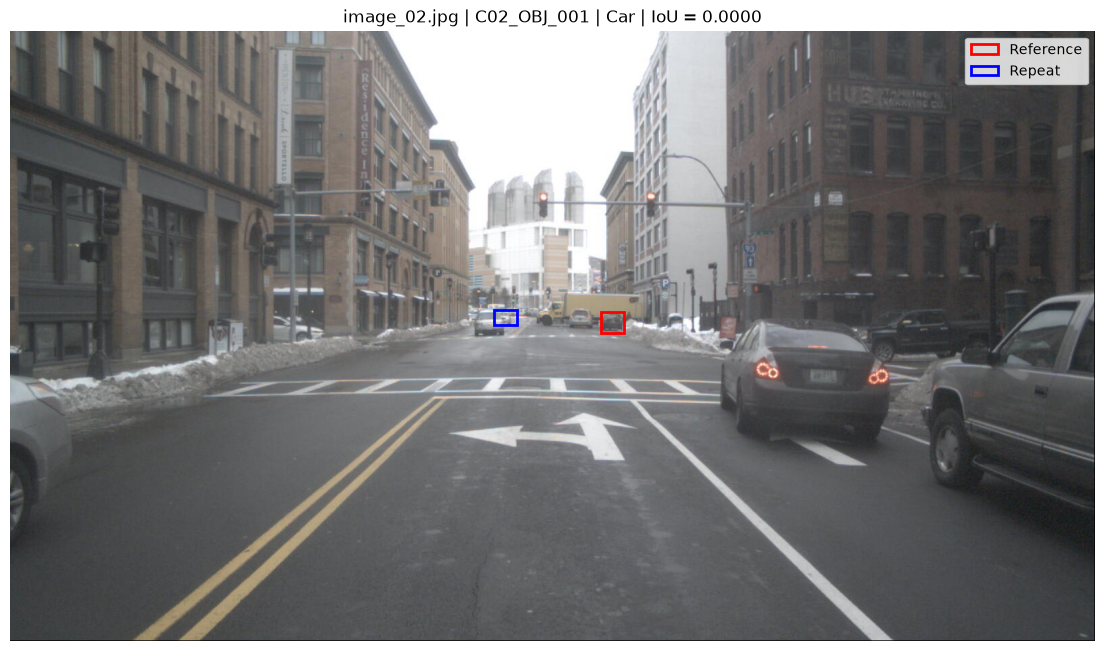

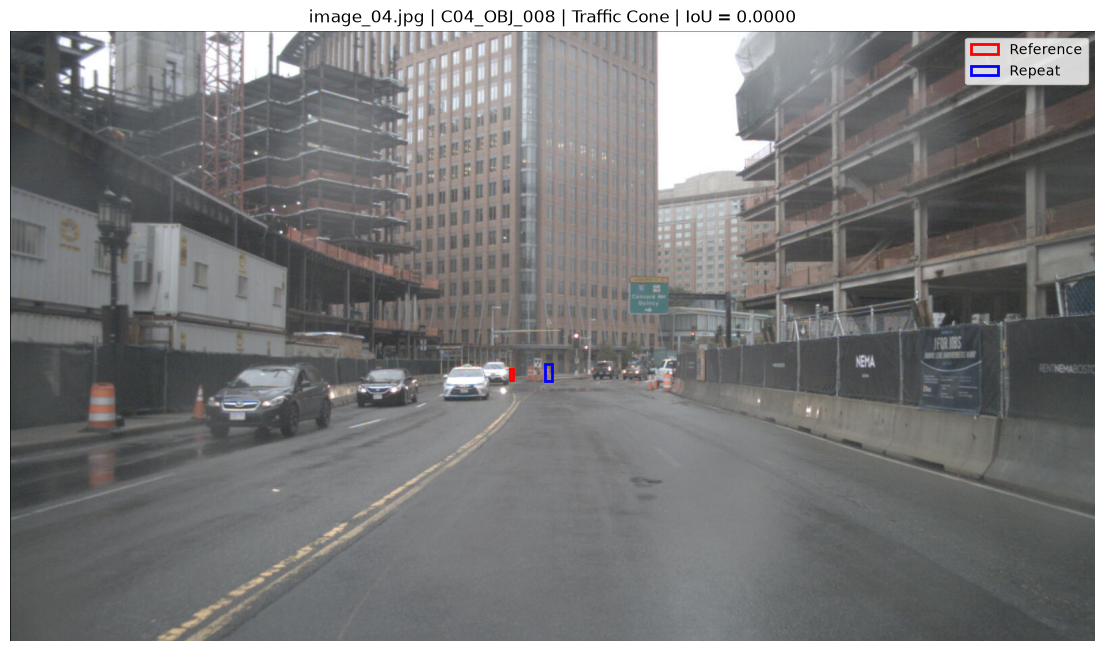

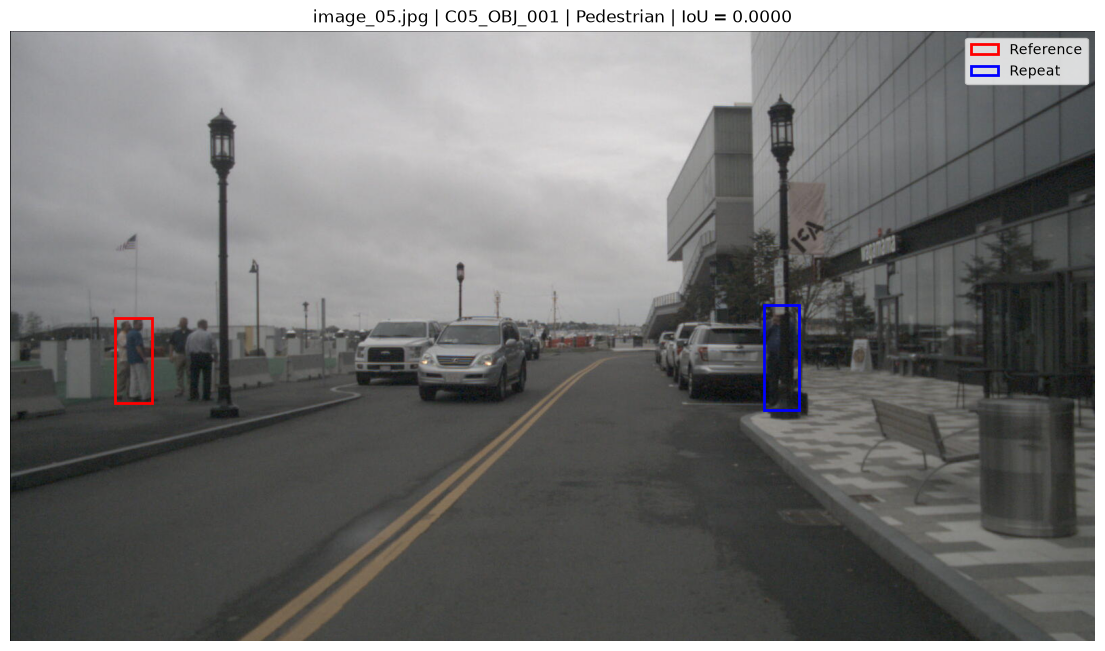

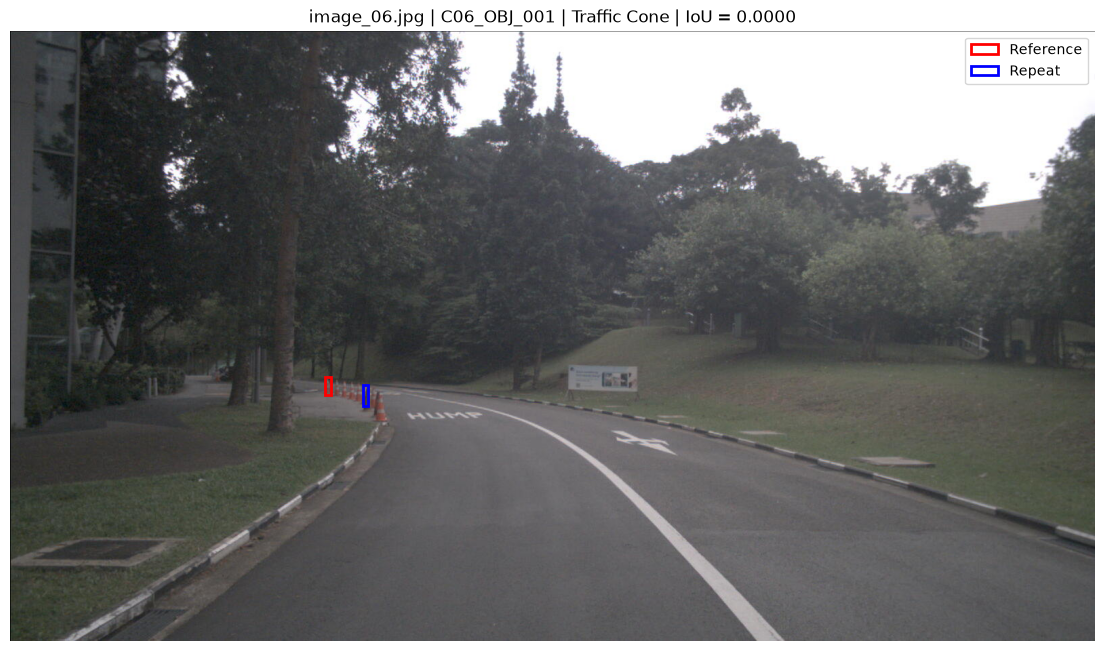

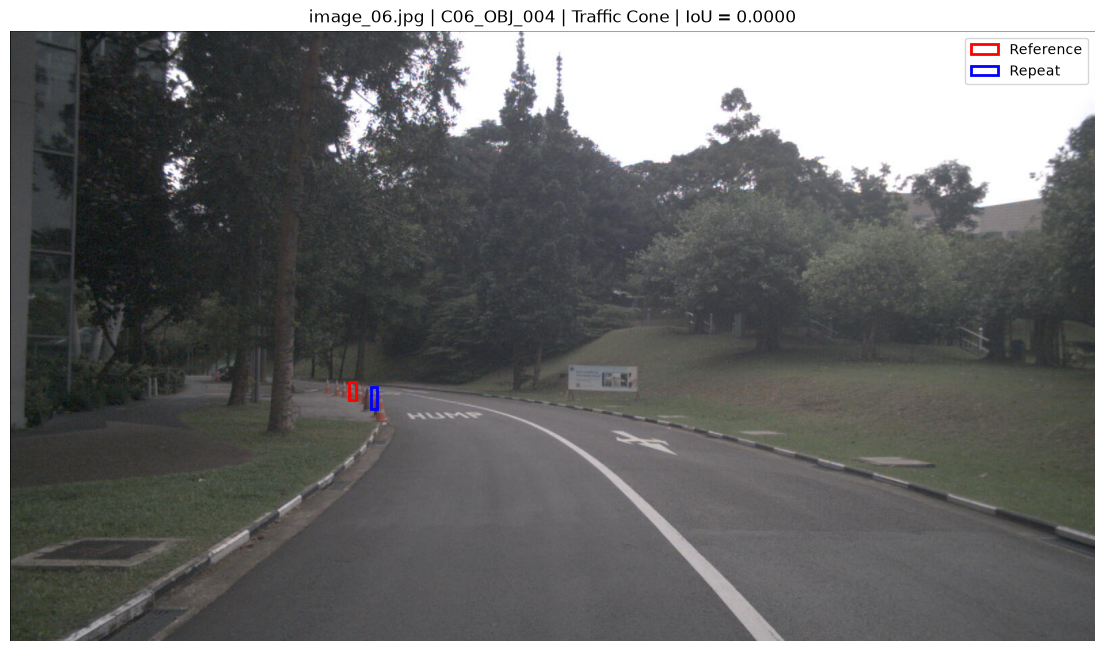

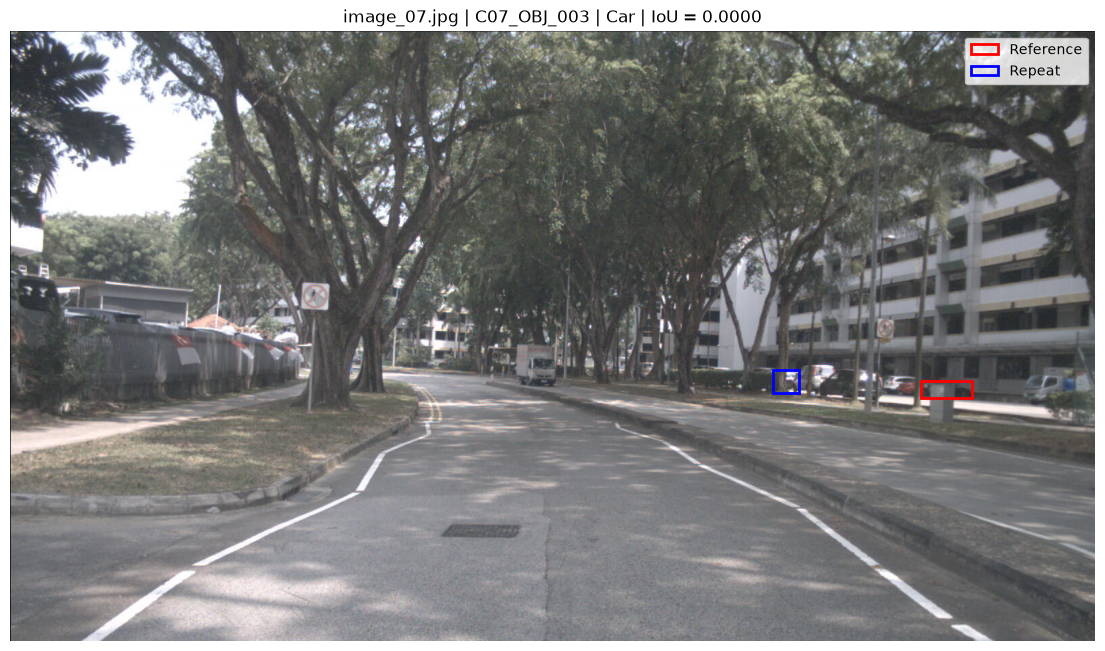

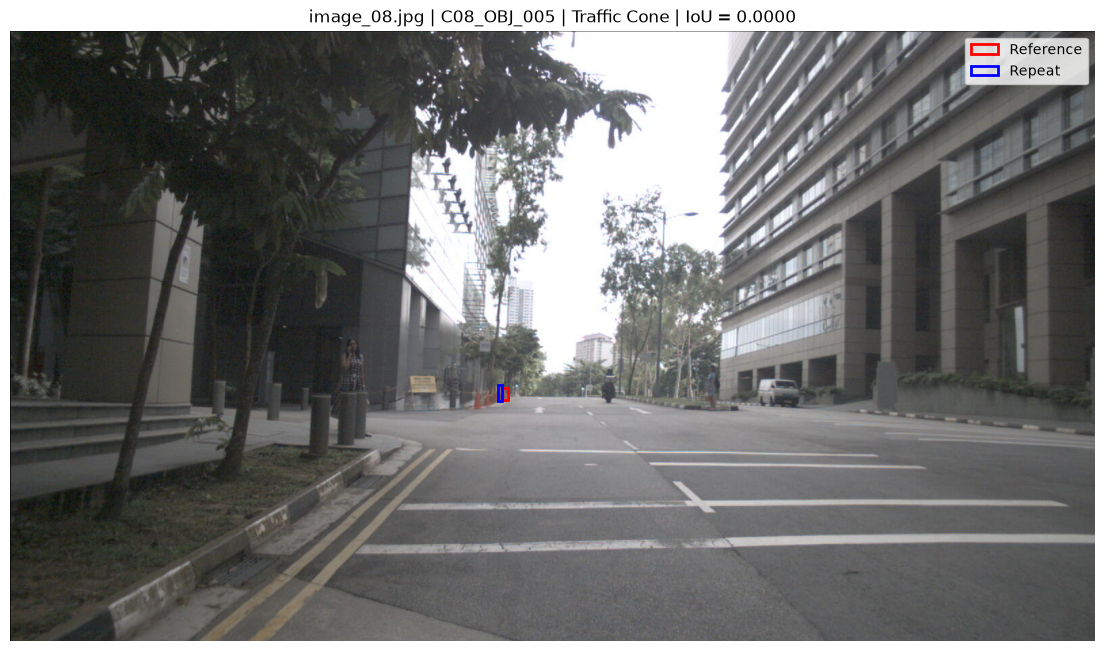

In [81]:
# Alias Image(별칭 이미지) → Original Image(원본 이미지) Mapping(매핑)
alias_to_original = dict(
    zip(
        mapping_df["alias_image"],
        mapping_df["original_image"]
    )
)

# Zero IoU(0 IoU) 사례 시각화
for _, row in zero_iou_cases.iterrows():

    alias_name = row["image_name"]
    original_name = alias_to_original[alias_name]
    image_path = image_dir / original_name

    # 이미지 로드
    img = Image.open(image_path)

    fig, ax = plt.subplots(figsize=(14, 8))
    ax.imshow(img)

    # Reference Bounding Box(기준 경계 상자)
    ref_width = row["ref_x_max"] - row["ref_x_min"]
    ref_height = row["ref_y_max"] - row["ref_y_min"]

    ref_rect = patches.Rectangle(
        (row["ref_x_min"], row["ref_y_min"]),
        ref_width,
        ref_height,
        linewidth=2,
        edgecolor="red",
        facecolor="none",
        label="Reference"
    )

    # Repeat Bounding Box(반복 경계 상자)
    repeat_width = row["repeat_x_max"] - row["repeat_x_min"]
    repeat_height = row["repeat_y_max"] - row["repeat_y_min"]

    repeat_rect = patches.Rectangle(
        (row["repeat_x_min"], row["repeat_y_min"]),
        repeat_width,
        repeat_height,
        linewidth=2,
        edgecolor="blue",
        facecolor="none",
        label="Repeat"
    )

    ax.add_patch(ref_rect)
    ax.add_patch(repeat_rect)

    ax.set_title(
        f"{alias_name} | "
        f"{row['reference_object_id']} | "
        f"{row['repeat_class']} | IoU = 0.0000"
    )

    ax.legend()
    ax.axis("off")

    plt.show()

#### IoU-09-4. Zero IoU Error Classification(0 IoU 오류 분류)

Zero IoU(0 IoU) 사례에 대해 Visual Validation(시각적 검증)을 수행하여
Reference Annotation(기준 라벨링)과 Repeat Annotation(반복 라벨링)이
동일한 객체를 대상으로 수행되었는지 확인한다.

오류는 다음과 같이 구분한다.

- Instance Selection Error(인스턴스 선택 오류): 동일 Class(클래스)의 다른 객체를 선택
- Localization Error(위치 지정 오류): 동일 객체를 선택했지만 Bounding Box(경계 상자)가 겹치지 않음
- Review Required(추가 검토 필요): 시각적으로 동일 객체 여부를 확정하기 어려움

In [82]:
# Zero IoU Error Classification(0 IoU 오류 분류)

zero_iou_review = zero_iou_cases.copy()

zero_iou_review["match_status"] = [
    "Different Object",   # image_02
    "Different Object",   # image_04
    "Different Object",   # image_05
    "Different Object",   # image_06 C06_OBJ_001
    "Different Object",   # image_06 C06_OBJ_004
    "Different Object",   # image_07
    "Review Required"     # image_08
]

zero_iou_review["error_type"] = [
    "Instance Selection Error",
    "Instance Selection Error",
    "Instance Selection Error",
    "Instance Selection Error",
    "Instance Selection Error",
    "Instance Selection Error",
    "Review Required"
]

# IoU Column(열) 추가
zero_iou_review["iou"] = 0.0

zero_iou_review[
    [
        "image_name",
        "reference_object_id",
        "repeat_class",
        "iou",
        "match_status",
        "error_type"
    ]
]

,image_name,reference_object_id,repeat_class,iou,match_status,error_type
2,image_02.jpg,C02_OBJ_001,Car,0.0,Different Object,Instance Selection Error
7,image_04.jpg,C04_OBJ_008,Traffic Cone,0.0,Different Object,Instance Selection Error
9,image_05.jpg,C05_OBJ_001,Pedestrian,0.0,Different Object,Instance Selection Error
10,image_06.jpg,C06_OBJ_001,Traffic Cone,0.0,Different Object,Instance Selection Error
11,image_06.jpg,C06_OBJ_004,Traffic Cone,0.0,Different Object,Instance Selection Error
13,image_07.jpg,C07_OBJ_003,Car,0.0,Different Object,Instance Selection Error
14,image_08.jpg,C08_OBJ_005,Traffic Cone,0.0,Review Required,Review Required


#### IoU-09-5. Detailed Review of Ambiguous Case(불확실 사례 상세 검토)

Visual Validation(시각적 검증)에서 동일 객체 여부가 명확하지 않은
image_08의 Traffic Cone을 확대하여 추가 검토한다.

Reference Bounding Box(기준 경계 상자)와
Repeat Bounding Box(반복 경계 상자)의 위치를 비교하여
Instance Selection Error(인스턴스 선택 오류)인지
Localization Error(위치 지정 오류)인지 최종 판정한다.

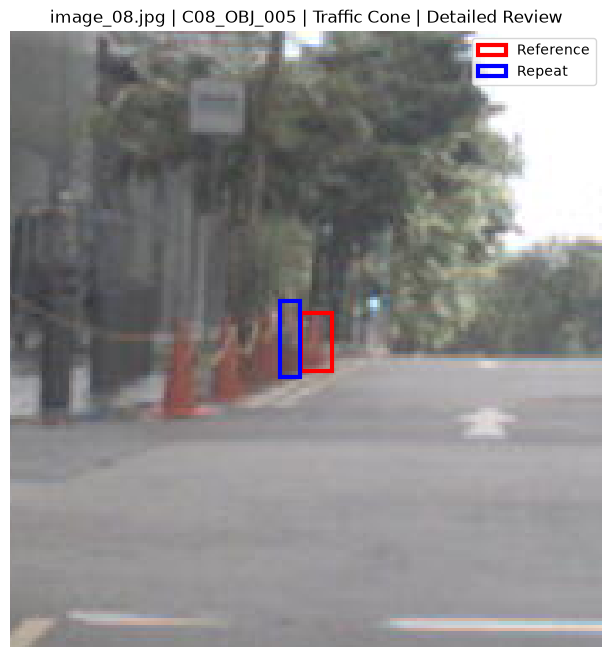

In [83]:
# Review Target(검토 대상)
review_case = zero_iou_review[
    zero_iou_review["match_status"] == "Review Required"
].iloc[0]

alias_name = review_case["image_name"]
original_name = alias_to_original[alias_name]
image_path = image_dir / original_name

img = Image.open(image_path)

# 두 Bounding Box(경계 상자)를 모두 포함하는 영역 계산
x_min = min(
    review_case["ref_x_min"],
    review_case["repeat_x_min"]
)
y_min = min(
    review_case["ref_y_min"],
    review_case["repeat_y_min"]
)
x_max = max(
    review_case["ref_x_max"],
    review_case["repeat_x_max"]
)
y_max = max(
    review_case["ref_y_max"],
    review_case["repeat_y_max"]
)

# 확대 영역 Margin(여백)
margin = 80

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(img)

# Reference Bounding Box(기준 경계 상자)
ref_rect = patches.Rectangle(
    (review_case["ref_x_min"], review_case["ref_y_min"]),
    review_case["ref_x_max"] - review_case["ref_x_min"],
    review_case["ref_y_max"] - review_case["ref_y_min"],
    linewidth=3,
    edgecolor="red",
    facecolor="none",
    label="Reference"
)

# Repeat Bounding Box(반복 경계 상자)
repeat_rect = patches.Rectangle(
    (review_case["repeat_x_min"], review_case["repeat_y_min"]),
    review_case["repeat_x_max"] - review_case["repeat_x_min"],
    review_case["repeat_y_max"] - review_case["repeat_y_min"],
    linewidth=3,
    edgecolor="blue",
    facecolor="none",
    label="Repeat"
)

ax.add_patch(ref_rect)
ax.add_patch(repeat_rect)

# Zoom(확대)
ax.set_xlim(max(0, x_min - margin), min(img.width, x_max + margin))
ax.set_ylim(
    min(img.height, y_max + margin),
    max(0, y_min - margin)
)

ax.set_title(
    "image_08.jpg | C08_OBJ_005 | Traffic Cone | Detailed Review"
)

ax.legend()
ax.axis("off")

plt.show()

#### IoU-09-6. Finalize Zero IoU Classification(0 IoU 분류 확정)

Detailed Visual Review(상세 시각적 검토)를 통해
7개의 Zero IoU(0 IoU) 사례를 최종 검증하였다.

모든 사례에서 Reference Annotation(기준 라벨링)과
Repeat Annotation(반복 라벨링)이 동일 Class(클래스)를 유지했지만,
서로 다른 Instance(인스턴스)를 선택한 것으로 확인되었다.

따라서 Zero IoU(0 IoU)의 주요 원인은
Bounding Box Localization Error(경계 상자 위치 지정 오류)가 아니라
Instance Selection Error(인스턴스 선택 오류)로 분류하였다.

In [84]:
# image_08 Final Classification(최종 분류)

mask = (
    (zero_iou_review["image_name"] == "image_08.jpg") &
    (zero_iou_review["reference_object_id"] == "C08_OBJ_005")
)

zero_iou_review.loc[mask, "match_status"] = "Different Object"
zero_iou_review.loc[mask, "error_type"] = "Instance Selection Error"

# Final Validation(최종 검증)
print("=== Zero IoU Final Classification ===")
print("Total Zero IoU Objects:", len(zero_iou_review))
print()

print("Match Status:")
print(zero_iou_review["match_status"].value_counts())
print()

print("Error Type:")
print(zero_iou_review["error_type"].value_counts())

zero_iou_review[
    [
        "image_name",
        "reference_object_id",
        "repeat_class",
        "iou",
        "match_status",
        "error_type"
    ]
]

=== Zero IoU Final Classification ===
Total Zero IoU Objects: 7

Match Status:
match_status
Different Object    7
Name: count, dtype: int64

Error Type:
error_type
Instance Selection Error    7
Name: count, dtype: int64


,image_name,reference_object_id,repeat_class,iou,match_status,error_type
2,image_02.jpg,C02_OBJ_001,Car,0.0,Different Object,Instance Selection Error
7,image_04.jpg,C04_OBJ_008,Traffic Cone,0.0,Different Object,Instance Selection Error
9,image_05.jpg,C05_OBJ_001,Pedestrian,0.0,Different Object,Instance Selection Error
10,image_06.jpg,C06_OBJ_001,Traffic Cone,0.0,Different Object,Instance Selection Error
11,image_06.jpg,C06_OBJ_004,Traffic Cone,0.0,Different Object,Instance Selection Error
13,image_07.jpg,C07_OBJ_003,Car,0.0,Different Object,Instance Selection Error
14,image_08.jpg,C08_OBJ_005,Traffic Cone,0.0,Different Object,Instance Selection Error


### IoU-10. Overall IoU Statistics(전체 IoU 통계)

전체 Repeat Annotation(반복 라벨링)을 대상으로
IoU Distribution(교차 영역 비율 분포)과 주요 Summary Statistics(요약 통계)를 분석한다.

분석 지표는 다음과 같다.

- Mean IoU(평균 IoU)
- Median IoU(중앙값 IoU)
- Minimum / Maximum IoU(최솟값 / 최댓값)
- Zero IoU Rate(0 IoU 비율)
- IoU ≥ 0.50 비율
- IoU ≥ 0.75 비율

이를 통해 Repeat Labeling(반복 라벨링)의
Bounding Box Consistency(경계 상자 일관성)를 정량적으로 평가한다.

In [85]:
# 현재 변수 확인
print([
    name for name in globals()
    if "iou" in name.lower()
])

['iou_sample_df', 'iou_zip_path', 'iou_df', 'calculate_iou', 'iou_results', 'zero_iou_cases', 'zero_iou_review', 'mean_iou', 'median_iou', 'min_iou', 'max_iou', 'zero_iou_count', 'zero_iou_rate', 'iou_50_count', 'iou_50_rate', 'iou_75_count', 'iou_75_rate', 'iou_values', 'iou_attr_df', 'iou_coord_cols']


In [86]:
# IoU Result DataFrame(IoU 결과 데이터프레임) 구조 확인

for name in ["iou_sample_df", "iou_df", "iou_results"]:
    df = globals()[name]

    print(f"\n=== {name} ===")
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())


=== iou_sample_df ===
Shape: (16, 8)
Columns: ['image_name', 'object_id', 'class_label', 'occlusion', 'truncation', 'small_distant', 'ambiguity', 'difficulty_score']

=== iou_df ===
Shape: (16, 13)
Columns: ['image_name', 'reference_object_id', 'repeat_class', 'repeat_x_min', 'repeat_y_min', 'repeat_x_max', 'repeat_y_max', 'reference_class', 'ref_x_min', 'ref_y_min', 'ref_x_max', 'ref_y_max', 'iou']

=== iou_results ===
Shape: (16, 4)
Columns: ['image_name', 'reference_object_id', 'repeat_class', 'iou']


#### IoU-10-2. Calculate Overall IoU Statistics(전체 IoU 통계 계산)

전체 16개 Repeat Annotation(반복 라벨링)의 IoU를 기반으로
Bounding Box Consistency(경계 상자 일관성)를 정량적으로 평가한다.

주요 지표는 Mean IoU(평균 IoU), Median IoU(중앙값 IoU),
Zero IoU Rate(0 IoU 비율), IoU Threshold(임계값)별 통과 비율을 사용한다.

In [87]:
# Overall IoU Statistics(전체 IoU 통계)

total_objects = len(iou_results)

mean_iou = iou_results["iou"].mean()
median_iou = iou_results["iou"].median()
min_iou = iou_results["iou"].min()
max_iou = iou_results["iou"].max()

zero_iou_count = (iou_results["iou"] == 0).sum()
zero_iou_rate = zero_iou_count / total_objects

iou_50_count = (iou_results["iou"] >= 0.50).sum()
iou_50_rate = iou_50_count / total_objects

iou_75_count = (iou_results["iou"] >= 0.75).sum()
iou_75_rate = iou_75_count / total_objects

print("=== Overall IoU Statistics ===")
print(f"Total Objects: {total_objects}")
print(f"Mean IoU: {mean_iou:.4f}")
print(f"Median IoU: {median_iou:.4f}")
print(f"Minimum IoU: {min_iou:.4f}")
print(f"Maximum IoU: {max_iou:.4f}")
print()
print(f"Zero IoU: {zero_iou_count}/{total_objects} ({zero_iou_rate:.2%})")
print(f"IoU >= 0.50: {iou_50_count}/{total_objects} ({iou_50_rate:.2%})")
print(f"IoU >= 0.75: {iou_75_count}/{total_objects} ({iou_75_rate:.2%})")

=== Overall IoU Statistics ===
Total Objects: 16
Mean IoU: 0.4780
Median IoU: 0.7085
Minimum IoU: 0.0000
Maximum IoU: 0.9549

Zero IoU: 7/16 (43.75%)
IoU >= 0.50: 9/16 (56.25%)
IoU >= 0.75: 7/16 (43.75%)


### IoU-10-3. IoU Distribution Analysis(IoU 분포 분석)

Repeat Labeling(반복 라벨링)의 Bounding Box(경계 상자) 일관성을 확인하기 위해
16개 객체의 IoU 분포를 시각화한다.

특히 IoU가 0인 사례와 높은 IoU를 기록한 사례가 어떻게 분포하는지 확인하여,
Localization Consistency(위치 일관성)와 Instance Selection Error(인스턴스 선택 오류)를
구분하여 평가한다.

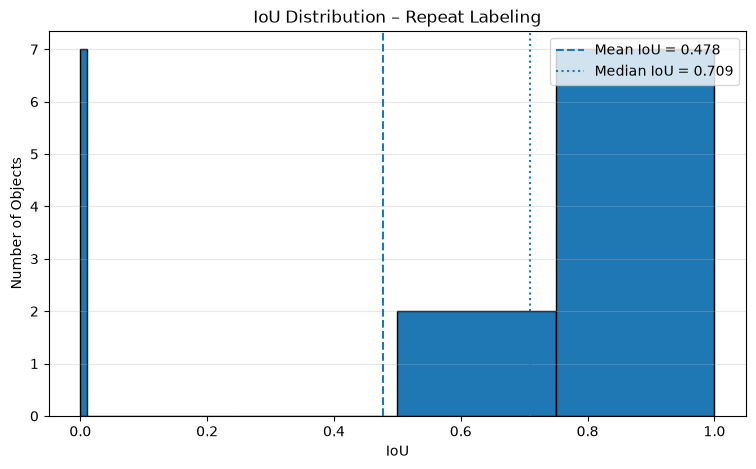

In [88]:
import matplotlib.pyplot as plt

# IoU 값
iou_values = iou_results["iou"]

# Histogram
plt.figure(figsize=(9, 5))

plt.hist(
    iou_values,
    bins=[0, 0.01, 0.25, 0.50, 0.75, 1.0],
    edgecolor="black"
)

# Reference lines
plt.axvline(
    iou_values.mean(),
    linestyle="--",
    label=f"Mean IoU = {iou_values.mean():.3f}"
)

plt.axvline(
    iou_values.median(),
    linestyle=":",
    label=f"Median IoU = {iou_values.median():.3f}"
)

plt.xlabel("IoU")
plt.ylabel("Number of Objects")
plt.title("IoU Distribution – Repeat Labeling")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

#### Observation

- 전체 16개 객체 중 **7개(43.75%)에서 IoU = 0**이 확인되었다.
- 나머지 **9개(56.25%)는 모두 IoU ≥ 0.50**을 기록하였다.
- 이 중 **7개(43.75%)는 IoU ≥ 0.75**로 비교적 높은 Bounding Box(경계 상자) 일관성을 보였다.
- Mean IoU(평균 IoU)는 **0.4780**, Median IoU(중앙값)는 **0.7085**로 나타났다.
- 앞선 Visual Review(시각적 검토) 결과, Zero IoU 7건은 모두 동일 객체의 Bounding Box 위치 차이가 아니라
  **서로 다른 객체를 선택한 Instance Selection Error(인스턴스 선택 오류)**로 확인되었다.
- 따라서 전체 IoU 저하는 Bounding Box Localization(경계 상자 위치 지정) 자체의 문제뿐 아니라
  **반복 라벨링 과정에서 동일 Instance(인스턴스)를 재선택하는 일관성**의 영향을 크게 받은 것으로 판단된다.

### IoU-10-4. Matched Instance IoU Analysis(동일 인스턴스 IoU 분석)

Overall IoU(전체 IoU)는 Instance Selection(인스턴스 선택)과
Bounding Box Localization(경계 상자 위치 지정)의 영향을 모두 포함한다.

앞선 Visual Review(시각적 검토)에서 IoU = 0인 7개 객체는 모두
서로 다른 객체를 선택한 Instance Selection Error(인스턴스 선택 오류)로 확인되었다.

따라서 동일 객체를 다시 선택한 사례만 별도로 분석하여
Bounding Box Localization Consistency(경계 상자 위치 일관성)를 평가한다.

In [89]:
# 동일 Instance(인스턴스)가 선택된 객체
matched_instance_df = iou_results[iou_results["iou"] > 0].copy()

print("=== Matched Instance IoU Statistics ===")
print(f"Matched Objects: {len(matched_instance_df)}")
print(
    f"Matched Rate: "
    f"{len(matched_instance_df) / len(iou_results) * 100:.2f}%"
)
print()

print(f"Mean IoU: {matched_instance_df['iou'].mean():.4f}")
print(f"Median IoU: {matched_instance_df['iou'].median():.4f}")
print(f"Minimum IoU: {matched_instance_df['iou'].min():.4f}")
print(f"Maximum IoU: {matched_instance_df['iou'].max():.4f}")

print()
print(
    "IoU >= 0.50:",
    (matched_instance_df["iou"] >= 0.50).sum(),
    f"/ {len(matched_instance_df)}"
)

print(
    "IoU >= 0.75:",
    (matched_instance_df["iou"] >= 0.75).sum(),
    f"/ {len(matched_instance_df)}"
)

=== Matched Instance IoU Statistics ===
Matched Objects: 9
Matched Rate: 56.25%

Mean IoU: 0.8497
Median IoU: 0.8962
Minimum IoU: 0.6713
Maximum IoU: 0.9549

IoU >= 0.50: 9 / 9
IoU >= 0.75: 7 / 9


#### Observation

- 전체 16개 Repeat Labeling(반복 라벨링) 객체 중 동일 Instance(인스턴스)를
  다시 선택한 객체는 **9개(56.25%)**였다.
- 동일 Instance를 선택한 9개 객체의 Mean IoU(평균 IoU)는 **0.8497**,
  Median IoU(중앙값)는 **0.8962**로 나타났다.
- Matched Instance(동일 인스턴스)의 IoU 범위는 **0.6713–0.9549**였다.
- 동일 Instance를 선택한 객체는 **9개 모두 IoU ≥ 0.50**을 기록했으며,
  **7개(77.78%)는 IoU ≥ 0.75**를 기록했다.
- Overall Mean IoU(전체 평균 IoU) **0.4780**과 비교하면,
  동일 Instance 선택 후의 Bounding Box Localization Consistency
  (경계 상자 위치 일관성)는 상대적으로 높게 나타났다.
- 따라서 Repeat Labeling에서 확인된 주요 오류 요인은
  Bounding Box Localization 자체보다 **Instance Selection Consistency
  (인스턴스 선택 일관성)**에 있는 것으로 분석된다.

### IoU-11-1. Attribute Consistency Analysis(속성 일관성 분석)

Reference Labeling(기준 라벨링)과 Repeat Labeling(반복 라벨링) 간의
Attribute Consistency(속성 일관성)를 평가한다.

비교 대상 Attribute(속성)는 다음과 같다.

- Occlusion(가림)
- Truncation(잘림)
- Small/Distant(소형·원거리 객체)
- Ambiguity(모호성)

각 Attribute의 일치 여부와 Agreement Rate(일치율)를 계산하여
반복 라벨링 과정에서 속성 판단의 일관성을 평가한다.

In [90]:
# Matched Instance만 선택
matched_ids = matched_instance_df[
    ["image_name", "reference_object_id"]
].copy()

# Reference Annotation에서 필요한 Attribute 가져오기
reference_attr = reference_df[
    [
        "image_name",
        "object_id",
        "occlusion",
        "truncation",
        "small_distant",
        "ambiguity"
    ]
].copy()

reference_attr = reference_attr.rename(
    columns={
        "object_id": "reference_object_id",
        "occlusion": "ref_occlusion",
        "truncation": "ref_truncation",
        "small_distant": "ref_small_distant",
        "ambiguity": "ref_ambiguity"
    }
)

# Repeat Annotation에서 필요한 Attribute 가져오기
repeat_attr = iou_df[
    [
        "image_name",
        "reference_object_id"
    ]
].copy()

# Repeat 원본 Attribute 연결
repeat_attr = repeat_attr.merge(
    repeat_df[
        [
            "image_name",
            "class_label",
            "occlusion",
            "truncation",
            "small_distant",
            "ambiguity"
        ]
    ],
    left_on=["image_name", "repeat_class"],
    right_on=["image_name", "class_label"],
    how="left"
) if "repeat_class" in repeat_attr.columns else None

In [91]:
print("=== iou_df Columns ===")
print(iou_df.columns.tolist())

print("\n=== repeat_df Columns ===")
print(repeat_df.columns.tolist())

=== iou_df Columns ===
['image_name', 'reference_object_id', 'repeat_class', 'repeat_x_min', 'repeat_y_min', 'repeat_x_max', 'repeat_y_max', 'reference_class', 'ref_x_min', 'ref_y_min', 'ref_x_max', 'ref_y_max', 'iou']

=== repeat_df Columns ===
['original_image_name', 'class_label', 'x_min', 'y_min', 'x_max', 'y_max', 'occlusion', 'truncation', 'small_distant', 'ambiguity', 'notes']


### IoU-11-2. Repeat Attribute Mapping(반복 속성 매핑)

Repeat Annotation(반복 라벨링) 데이터에는 별도의 Object ID(객체 ID)가 없으므로,
Image Name(이미지명)과 Bounding Box Coordinate(경계 상자 좌표)를 이용하여
IoU 분석 결과와 Repeat Attribute(반복 속성)를 연결한다.

이를 통해 동일 이미지 내에 동일 Class(클래스)가 여러 개 존재하는 경우에도
잘못된 객체 간 Attribute 비교를 방지한다.

In [92]:
# Repeat Annotation에 alias image_name 연결
repeat_attr_df = repeat_df.merge(
    mapping_df[
        ["alias_image", "original_image"]
    ],
    left_on="original_image_name",
    right_on="original_image",
    how="left"
)

repeat_attr_df = repeat_attr_df.rename(
    columns={"alias_image": "image_name"}
)

print("=== Repeat Attribute Mapping ===")
print("Rows:", len(repeat_attr_df))
print(
    "Mapped Images:",
    repeat_attr_df["image_name"].notna().sum()
)
print(
    "Unmapped Images:",
    repeat_attr_df["image_name"].isna().sum()
)

repeat_attr_df[
    [
        "image_name",
        "class_label",
        "x_min",
        "y_min",
        "x_max",
        "y_max",
        "occlusion",
        "truncation",
        "small_distant",
        "ambiguity"
    ]
]

=== Repeat Attribute Mapping ===
Rows: 16
Mapped Images: 16
Unmapped Images: 0


,image_name,class_label,x_min,y_min,x_max,y_max,occlusion,truncation,small_distant,ambiguity
0,image_01.jpg,Barrier,2.03,456.80,252.41,578.57,Partial,Partial,false,None
1,image_01.jpg,Construction Vehicle,0.00,401.50,237.74,459.02,Partial,None,false,None
2,image_02.jpg,Car,713.68,411.60,747.60,434.21,Partial,None,true,None
3,image_02.jpg,Car,0.00,506.39,90.00,757.89,None,Heavy,false,None
4,image_03.jpg,Car,721.83,427.40,748.65,453.00,Heavy,None,true,Class
5,image_03.jpg,Truck,889.93,425.55,923.11,456.80,None,None,true,Class
6,image_04.jpg,Car,952.78,482.51,983.95,522.11,Partial,None,true,Class
7,image_04.jpg,Traffic Cone,788.96,491.25,798.14,516.17,None,None,true,None
8,image_05.jpg,Car,951.65,443.23,978.72,491.73,Heavy,None,true,Class
9,image_05.jpg,Pedestrian,1110.70,403.76,1163.70,558.27,Partial,None,false,None


### IoU-11-3. Object-level Attribute Matching(객체 수준 속성 매칭)

IoU 분석에서 확인된 Repeat Bounding Box(반복 경계 상자) 좌표와
Repeat Annotation(반복 라벨링)의 Bounding Box 좌표를 이용하여
각 객체의 Attribute(속성)를 연결한다.

좌표의 Floating-point Precision(부동소수점 정밀도) 차이로 인한
매핑 오류를 방지하기 위해 좌표를 소수점 둘째 자리로 통일하여 비교한다.

In [93]:
# IoU 데이터 복사
iou_attr_df = iou_df.copy()

# Repeat Attribute 데이터 복사
repeat_attr_merge = repeat_attr_df.copy()

# 좌표를 소수점 둘째 자리로 통일
iou_coord_cols = [
    "repeat_x_min",
    "repeat_y_min",
    "repeat_x_max",
    "repeat_y_max"
]

repeat_coord_cols = [
    "x_min",
    "y_min",
    "x_max",
    "y_max"
]

for col in iou_coord_cols:
    iou_attr_df[col] = iou_attr_df[col].round(2)

for col in repeat_coord_cols:
    repeat_attr_merge[col] = repeat_attr_merge[col].round(2)

# Repeat Attribute 연결
iou_attr_df = iou_attr_df.merge(
    repeat_attr_merge[
        [
            "image_name",
            "x_min",
            "y_min",
            "x_max",
            "y_max",
            "occlusion",
            "truncation",
            "small_distant",
            "ambiguity"
        ]
    ],
    left_on=[
        "image_name",
        "repeat_x_min",
        "repeat_y_min",
        "repeat_x_max",
        "repeat_y_max"
    ],
    right_on=[
        "image_name",
        "x_min",
        "y_min",
        "x_max",
        "y_max"
    ],
    how="left"
)

# 불필요한 좌표 제거
iou_attr_df = iou_attr_df.drop(
    columns=["x_min", "y_min", "x_max", "y_max"]
)

print("=== Object-level Attribute Mapping ===")
print("Total Objects:", len(iou_attr_df))

print(
    "Mapped Attributes:",
    iou_attr_df["occlusion"].notna().sum()
)

print(
    "Unmapped Attributes:",
    iou_attr_df["occlusion"].isna().sum()
)

iou_attr_df[
    [
        "image_name",
        "reference_object_id",
        "repeat_class",
        "iou",
        "occlusion",
        "truncation",
        "small_distant",
        "ambiguity"
    ]
]

=== Object-level Attribute Mapping ===
Total Objects: 16
Mapped Attributes: 16
Unmapped Attributes: 0


,image_name,reference_object_id,repeat_class,iou,occlusion,truncation,small_distant,ambiguity
0,image_01.jpg,C01_OBJ_002,Barrier,0.902978,Partial,Partial,false,None
1,image_01.jpg,C01_OBJ_007,Construction Vehicle,0.919665,Partial,None,false,None
2,image_02.jpg,C02_OBJ_001,Car,0.000000,Partial,None,true,None
3,image_02.jpg,C02_OBJ_004,Car,0.954900,None,Heavy,false,None
4,image_03.jpg,C03_OBJ_002,Car,0.816890,Heavy,None,true,Class
5,image_03.jpg,C03_OBJ_005,Truck,0.896235,None,None,true,Class
6,image_04.jpg,C04_OBJ_014,Car,0.843165,Partial,None,true,Class
7,image_04.jpg,C04_OBJ_008,Traffic Cone,0.000000,None,None,true,None
8,image_05.jpg,C05_OBJ_003,Car,0.671258,Heavy,None,true,Class
9,image_05.jpg,C05_OBJ_001,Pedestrian,0.000000,Partial,None,false,None


### IoU-11-4. Reference vs Repeat Attribute Comparison(기준-반복 속성 비교)

동일 Instance(인스턴스)를 선택한 객체를 대상으로 Reference Labeling(기준 라벨링)과
Repeat Labeling(반복 라벨링)의 Attribute(속성)를 비교한다.

Instance Selection Error(인스턴스 선택 오류)가 발생한 객체는 서로 다른 객체의
속성을 비교하게 되므로 Attribute Agreement(속성 일치율) 계산에서 제외한다.

In [94]:
# Reference Attribute 준비
reference_attr_df = reference_df[
    [
        "image_name",
        "object_id",
        "occlusion",
        "truncation",
        "small_distant",
        "ambiguity"
    ]
].copy()

reference_attr_df = reference_attr_df.rename(
    columns={
        "object_id": "reference_object_id",
        "occlusion": "ref_occlusion",
        "truncation": "ref_truncation",
        "small_distant": "ref_small_distant",
        "ambiguity": "ref_ambiguity"
    }
)

# Reference Attribute 연결
attribute_compare_df = iou_attr_df.merge(
    reference_attr_df,
    on=["image_name", "reference_object_id"],
    how="left"
)

# 동일 Instance만 선택
matched_attribute_df = attribute_compare_df[
    attribute_compare_df["iou"] > 0
].copy()

print("=== Matched Instance Attribute Dataset ===")
print("Objects:", len(matched_attribute_df))

matched_attribute_df[
    [
        "image_name",
        "reference_object_id",
        "ref_occlusion",
        "occlusion",
        "ref_truncation",
        "truncation",
        "ref_small_distant",
        "small_distant",
        "ref_ambiguity",
        "ambiguity"
    ]
]

=== Matched Instance Attribute Dataset ===
Objects: 9


,image_name,reference_object_id,ref_occlusion,occlusion,ref_truncation,truncation,ref_small_distant,small_distant,ref_ambiguity,ambiguity
0,image_01.jpg,C01_OBJ_002,Partial,Partial,Partial,Partial,False,false,NaN,None
1,image_01.jpg,C01_OBJ_007,Partial,Partial,NaN,None,False,false,NaN,None
3,image_02.jpg,C02_OBJ_004,NaN,None,Heavy,Heavy,False,false,NaN,None
4,image_03.jpg,C03_OBJ_002,Heavy,Heavy,NaN,None,True,true,Class,Class
5,image_03.jpg,C03_OBJ_005,NaN,None,NaN,None,True,true,Class,Class
6,image_04.jpg,C04_OBJ_014,Partial,Partial,NaN,None,True,true,Class,Class
8,image_05.jpg,C05_OBJ_003,Heavy,Heavy,NaN,None,True,true,Class,Class
12,image_07.jpg,C07_OBJ_002,Partial,Partial,Partial,Partial,False,false,Boundary,Boundary
15,image_08.jpg,C08_OBJ_006,Partial,Partial,NaN,None,True,true,Boundary,Boundary


In [95]:
print("\n=== Reference Attribute Missing Check ===")

check_cols = [
    "ref_occlusion",
    "ref_truncation",
    "ref_small_distant",
    "ref_ambiguity"
]

print(
    matched_attribute_df[check_cols]
    .isna()
    .sum()
)


=== Reference Attribute Missing Check ===
ref_occlusion        2
ref_truncation       6
ref_small_distant    0
ref_ambiguity        3
dtype: int64


### IoU-11-5. Attribute Value Normalization(속성값 표준화)

CSV 로드 과정에서 문자열 `None`이 NaN으로 변환된 Reference Attribute(기준 속성)를
원래 라벨 값인 `None`으로 복원한다.

이를 통해 Reference Labeling(기준 라벨링)과 Repeat Labeling(반복 라벨링)의
Attribute Value(속성값)를 동일한 형식으로 표준화한 후 Agreement Rate(일치율)를 계산한다.

In [96]:
# Reference의 NaN을 실제 Attribute 값 "None"으로 복원
ref_attribute_cols = [
    "ref_occlusion",
    "ref_truncation",
    "ref_ambiguity"
]

for col in ref_attribute_cols:
    matched_attribute_df[col] = (
        matched_attribute_df[col]
        .fillna("None")
    )

# Boolean 값도 동일한 형식으로 통일
matched_attribute_df["ref_small_distant"] = (
    matched_attribute_df["ref_small_distant"]
    .astype(str)
    .str.lower()
)

matched_attribute_df["small_distant"] = (
    matched_attribute_df["small_distant"]
    .astype(str)
    .str.lower()
)

# 표준화 결과 확인
print("=== Attribute Normalization Check ===")

print(
    matched_attribute_df[
        [
            "ref_occlusion",
            "ref_truncation",
            "ref_small_distant",
            "ref_ambiguity"
        ]
    ].isna().sum()
)

=== Attribute Normalization Check ===
ref_occlusion        0
ref_truncation       0
ref_small_distant    0
ref_ambiguity        0
dtype: int64


In [97]:
# Attribute별 일치 여부 계산
matched_attribute_df["occlusion_match"] = (
    matched_attribute_df["ref_occlusion"]
    == matched_attribute_df["occlusion"]
)

matched_attribute_df["truncation_match"] = (
    matched_attribute_df["ref_truncation"]
    == matched_attribute_df["truncation"]
)

matched_attribute_df["small_distant_match"] = (
    matched_attribute_df["ref_small_distant"]
    == matched_attribute_df["small_distant"]
)

matched_attribute_df["ambiguity_match"] = (
    matched_attribute_df["ref_ambiguity"]
    == matched_attribute_df["ambiguity"]
)

# Agreement Rate 계산
agreement_cols = {
    "Occlusion": "occlusion_match",
    "Truncation": "truncation_match",
    "Small/Distant": "small_distant_match",
    "Ambiguity": "ambiguity_match"
}

print("=== Attribute Agreement Rate ===")

for attribute, col in agreement_cols.items():
    matched = matched_attribute_df[col].sum()
    total = len(matched_attribute_df)
    rate = matched / total * 100

    print(
        f"{attribute}: "
        f"{matched}/{total} ({rate:.2f}%)"
    )

=== Attribute Agreement Rate ===
Occlusion: 9/9 (100.00%)
Truncation: 9/9 (100.00%)
Small/Distant: 9/9 (100.00%)
Ambiguity: 9/9 (100.00%)


### IoU-11-7. Overall Attribute Agreement(전체 속성 일치율)

Matched Instance(동일 인스턴스) 9개를 대상으로 4개 Attribute(속성)의
개별 Agreement Rate(일치율)와 Overall Attribute Agreement
(전체 속성 일치율)를 계산한다.

이를 통해 동일 객체가 선택된 경우 Attribute 판단이 반복 라벨링에서도
얼마나 일관되게 적용되었는지 평가한다.

In [98]:
# Attribute별 결과 정리
attribute_summary = []

for attribute, col in agreement_cols.items():
    matched = int(matched_attribute_df[col].sum())
    total = len(matched_attribute_df)
    rate = matched / total * 100

    attribute_summary.append({
        "attribute": attribute,
        "matched": matched,
        "total": total,
        "agreement_rate": rate
    })

attribute_summary_df = pd.DataFrame(attribute_summary)

# 전체 Attribute Agreement
match_columns = list(agreement_cols.values())

total_attribute_decisions = (
    len(matched_attribute_df) * len(match_columns)
)

total_attribute_matches = (
    matched_attribute_df[match_columns]
    .sum()
    .sum()
)

overall_attribute_agreement = (
    total_attribute_matches
    / total_attribute_decisions
    * 100
)

print("=== Attribute Agreement Summary ===")
display(attribute_summary_df)

print()
print(
    f"Overall Attribute Agreement: "
    f"{total_attribute_matches}/{total_attribute_decisions} "
    f"({overall_attribute_agreement:.2f}%)"
)

=== Attribute Agreement Summary ===


,attribute,matched,total,agreement_rate
0,Occlusion,9,9,100.0
1,Truncation,9,9,100.0
2,Small/Distant,9,9,100.0
3,Ambiguity,9,9,100.0



Overall Attribute Agreement: 36/36 (100.00%)


### IoU-11-8. Observation & Key Finding(관찰 및 핵심 결과)

#### Observation

- 전체 16개 Repeat Labeling(반복 라벨링) 객체 중 동일 Instance(인스턴스)를
  다시 선택한 객체는 **9개(56.25%)**였다.
- Matched Instance(동일 인스턴스) 9개의 Mean IoU(평균 IoU)는
  **0.8497**, Median IoU(중앙값)는 **0.8962**였다.
- 동일 Instance 9개 모두 **IoU ≥ 0.50**을 기록했으며,
  이 중 **7개(77.78%)는 IoU ≥ 0.75**를 기록했다.
- Matched Instance를 대상으로 Attribute Consistency(속성 일관성)를 평가한 결과,
  Occlusion(가림), Truncation(잘림), Small/Distant(소형·원거리),
  Ambiguity(모호성) 모두 **9/9 (100%)** 일치하였다.
- 총 **36개 Attribute Decision(속성 판단) 중 36개가 일치하여
  Overall Attribute Agreement(전체 속성 일치율)는 100%**로 나타났다.

#### Key Finding

Repeat Labeling QA 결과, 동일 Instance가 선택된 경우에는
Bounding Box Localization(경계 상자 위치 지정)과 Attribute Assignment
(속성 부여)에서 높은 일관성이 확인되었다.

반면 전체 16개 객체 중 **7개(43.75%)에서 서로 다른 Instance를 선택하여
IoU = 0**이 발생하였다. 따라서 이번 Pilot QA(파일럿 품질 검증)에서 확인된
주요 개선 영역은 Bounding Box 또는 Attribute 판단 자체보다
**Instance Selection Consistency(인스턴스 선택 일관성)**이다.

향후 반복 라벨링에서는 대상 객체를 보다 명확하게 식별할 수 있도록
Object ID(객체 ID), 객체 위치, 주변 객체와의 상대적 위치 등
Instance Identification Rule(인스턴스 식별 규칙)을 강화할 필요가 있다.

### IoU-12. QA Summary & Improvement Action(QA 요약 및 개선 조치)

Repeat Labeling(반복 라벨링)을 통해 Bounding Box(경계 상자),
Instance Selection(인스턴스 선택), Attribute Assignment(속성 부여)의
일관성을 종합적으로 평가하였다.

#### QA Summary

| QA Metric(품질 지표) | Result(결과) |
|---|---:|
| Repeat Labeling Objects | 16 |
| Evaluated Images | 8 |
| Class Match | 16/16 (100%) |
| Instance Selection Consistency | 9/16 (56.25%) |
| Overall Mean IoU | 0.4780 |
| Overall Median IoU | 0.7085 |
| Zero IoU | 7/16 (43.75%) |
| Matched-instance Mean IoU | 0.8497 |
| Matched-instance Median IoU | 0.8962 |
| Matched-instance IoU ≥ 0.50 | 9/9 (100%) |
| Matched-instance IoU ≥ 0.75 | 7/9 (77.78%) |
| Occlusion Agreement | 9/9 (100%) |
| Truncation Agreement | 9/9 (100%) |
| Small/Distant Agreement | 9/9 (100%) |
| Ambiguity Agreement | 9/9 (100%) |
| Overall Attribute Agreement | 36/36 (100%) |

#### Root Cause Analysis(근본 원인 분석)

Overall Mean IoU(전체 평균 IoU)는 **0.4780**으로 나타났지만,
Zero IoU 7건을 Visual Review(시각적 검토)한 결과 모두
**Instance Selection Error(인스턴스 선택 오류)**로 확인되었다.

동일 Instance를 정확하게 선택한 9건에서는 Mean IoU가 **0.8497**로 상승했으며,
4개 Attribute의 Overall Agreement도 **100%**를 기록하였다.

따라서 주요 QA Risk(품질 위험)는 Class Selection(클래스 선택)이나
Attribute Assignment보다 **동일 객체를 반복적으로 식별하는 과정**에서 확인되었다.

#### Improvement Actions(개선 조치)

1. **Instance Identification Rule(인스턴스 식별 규칙) 강화**
   - Class뿐 아니라 객체의 위치와 주변 객체와의 상대적 위치를 함께 확인한다.
   - 동일 Class 객체가 여러 개 존재하는 경우 좌→우 또는 근거리→원거리와 같은
     일관된 식별 순서를 적용한다.

2. **Object ID 기반 QA 적용**
   - Repeat Labeling 전에 평가 대상 Object ID와 위치 정보를 명확하게 기록한다.
   - 동일 객체를 다시 선택했는지 검증한 후 Bounding Box 품질을 평가한다.

3. **Small/Distant Object(소형·원거리 객체) 식별 기준 강화**
   - 작은 객체가 밀집된 장면에서는 Zoom(확대)을 활용하여 객체 경계를 확인한다.
   - Traffic Cone, Car 등 반복적으로 등장하는 객체의 Instance 혼동을 우선 점검한다.

4. **QA Metric 분리**
   - Instance Selection Consistency와 Bounding Box Localization Consistency를
     별도의 품질 지표로 관리한다.
   - Attribute Agreement는 Matched Instance를 기준으로 별도 평가한다.

#### Final Conclusion(최종 결론)

이번 Repeat Labeling QA에서는 동일 Instance가 선택된 경우
Bounding Box Localization과 Attribute Assignment에서 높은 일관성이 확인되었다.

반면 Instance Selection Consistency는 **56.25%**로 나타나,
반복 라벨링 시 동일 객체를 정확하게 재식별하는 절차가 핵심 개선 영역으로 확인되었다.

향후 Instance Identification Rule과 Object ID 기반 QA 절차를 강화함으로써
전체 라벨링 재현성과 품질을 개선할 수 있다.